# Publication-ready patient-level 10-fold evaluation of QGECAF

This notebook implements Steps 1–12 as one locked analysis pipeline:

1. Load the fixed patient-level `train/val/test` folders.
2. Link every image to the patient ID in the original split CSV.
3. Audit zero patient overlap among the original splits.
4. Combine only original train+validation patients into the development cohort.
5. Generate deterministic 10-fold `StratifiedGroupKFold` assignments.
6. Create a group-disjoint inner validation subset for early stopping.
7. Refit standardization, family-wise PCA and **patient-grouped BGWO** inside every fold.
8. Train a fresh QGECAF model and evaluate the outer patient-held-out fold.
9. Save fold metrics, exactly-once out-of-fold predictions, mean, SD and 95% CI.
10. Select the final training duration using the median best epoch across folds.
11. Refit preprocessing and train on all development patients.
12. Evaluate the original test patients exactly once and save publication-ready outputs.

**Important:** Change only the paths and CSV column names in the configuration cell. Do not place test patients into the 10-fold development cohort.


## Cell 1 — Complete implementation

Run this cell once. It defines feature extraction, group-aware BGWO, QGECAF, evaluation, statistical aggregation and final hold-out testing. No training starts in this cell.


In [1]:
"""Publication-ready patient-level 10-fold evaluation of QGECAF.

The existing test patients remain untouched. The original train and validation
patients form the development cohort used for ten patient-grouped outer folds.
Every fold independently fits standardization, family-wise PCA, group-aware
BGWO, class weights and a fresh QGECAF model. Out-of-fold predictions, fold
assignments, confidence intervals and the final untouched-test result are saved.

Run this file from Jupyter with ``%run QGECAF_Patient_Level_10Fold_Publication_Ready.py``
or execute its cells in the generated companion notebook.
"""

from __future__ import annotations

import argparse
import json
import math
import os
import random
import warnings
import hashlib
import gc
from itertools import combinations
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_DETERMINISTIC_OPS", "1")

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
import seaborn as sns
import tensorflow as tf
from scipy.stats import spearmanr, t, friedmanchisquare, wilcoxon
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern
from skimage.measure import label, regionprops, shannon_entropy

try:
    from kymatio.numpy import Scattering2D
except Exception:
    Scattering2D = None


IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
FAMILY_NAMES = ("wst", "gabor", "lbp", "hog", "shape")
QUALITY_NAMES = ("blur", "brightness", "contrast", "entropy", "noise", "background")


@dataclass
class Config:
    dataset: str = r"D:\chaitali\patientsplit801010_clean_v2"
    metadata_csv: str = r"D:\chaitali\patientsplit801010_clean_v2\patient_split_80_10_10.csv"
    patient_column: str = "Patient_num"
    image_column: str = "Image_name"
    output: str = r"D:\chaitali\quality_gated_evidential_fusion\QGECAF_FROM_SCRATCH_RUN_01"
    image_size: int = 128
    seed: int = 42
    test_size: float = 0.15
    val_size: float = 0.15
    pca_variance: float = 0.98
    bgwo_agents: int = 12
    bgwo_iters: int = 25
    bgwo_cv: int = 3
    bgwo_alpha: float = 0.99
    embed_dim: int = 64
    attention_heads: int = 4
    batch_size: int = 8
    epochs: int = 40
    learning_rate: float = 1e-4
    kl_weight: float = 1e-3
    dropout: float = 0.30
    fine_tune_last: int = 30
    force_features: bool = False
    smoke_test: bool = False
    outer_folds: int = 10
    inner_folds: int = 9
    early_stopping_patience: int = 8
    resume: bool = True


def parse_args() -> Config:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--dataset", default=Config.dataset)
    parser.add_argument("--metadata-csv", default=Config.metadata_csv)
    parser.add_argument("--patient-column", default=Config.patient_column)
    parser.add_argument("--image-column", default=Config.image_column)
    parser.add_argument("--output", default=Config.output)
    parser.add_argument("--image-size", type=int, default=Config.image_size)
    parser.add_argument("--seed", type=int, default=Config.seed)
    parser.add_argument("--pca-variance", type=float, default=Config.pca_variance)
    parser.add_argument("--bgwo-agents", type=int, default=Config.bgwo_agents)
    parser.add_argument("--bgwo-iters", type=int, default=Config.bgwo_iters)
    parser.add_argument("--bgwo-cv", type=int, default=Config.bgwo_cv)
    parser.add_argument("--embed-dim", type=int, default=Config.embed_dim)
    parser.add_argument("--attention-heads", type=int, default=Config.attention_heads)
    parser.add_argument("--batch-size", type=int, default=Config.batch_size)
    parser.add_argument("--epochs", type=int, default=Config.epochs)
    parser.add_argument("--learning-rate", type=float, default=Config.learning_rate)
    parser.add_argument("--fine-tune-last", type=int, default=Config.fine_tune_last)
    parser.add_argument("--force-features", action="store_true")
    parser.add_argument("--smoke-test", action="store_true")
    parser.add_argument("--outer-folds", type=int, default=Config.outer_folds)
    parser.add_argument("--inner-folds", type=int, default=Config.inner_folds)
    parser.add_argument("--no-resume", action="store_false", dest="resume")
    return Config(**vars(parser.parse_args()))


def set_reproducibility(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except (AttributeError, RuntimeError):
        pass


def configure_gpu() -> None:
    gpus = tf.config.list_physical_devices("GPU")
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass
    print(f"TensorFlow {tf.__version__}; GPUs detected: {len(gpus)}")


def discover_dataset(dataset_dir: Path) -> Tuple[List[Path], np.ndarray, List[str]]:
    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"Dataset directory was not found: {dataset_dir}\n"
            "Check the drive letter and folder spelling."
        )
    class_dirs = sorted([p for p in dataset_dir.iterdir() if p.is_dir()], key=lambda p: p.name.lower())
    if len(class_dirs) < 2:
        raise ValueError("The dataset folder must contain one subfolder per class.")

    paths: List[Path] = []
    labels: List[int] = []
    names = [p.name for p in class_dirs]
    for class_index, class_dir in enumerate(class_dirs):
        class_images = sorted(
            p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
        print(f"{class_dir.name}: {len(class_images)} images")
        paths.extend(class_images)
        labels.extend([class_index] * len(class_images))

    if not paths:
        raise ValueError("No supported images were found in the class folders.")
    return paths, np.asarray(labels, dtype=np.int32), names


def discover_presplit_dataset(
    dataset_root: Path,
) -> Tuple[List[Path], np.ndarray, List[str], np.ndarray]:
    """Read a fixed train/val/test directory without creating a new split.

    Expected layout::

        dataset_root/train/<class_name>/*.png
        dataset_root/val/<class_name>/*.png
        dataset_root/test/<class_name>/*.png

    A single class-to-index mapping is learned from the training folders and
    reused for validation and testing, preventing label-index inconsistencies.
    """
    if not dataset_root.exists():
        raise FileNotFoundError(f"Pre-split dataset root was not found: {dataset_root}")

    split_aliases = {"train": "train", "val": "validation", "test": "test"}
    for folder in split_aliases:
        if not (dataset_root / folder).is_dir():
            raise FileNotFoundError(
                f"Required split folder is missing: {dataset_root / folder}"
            )

    train_class_dirs = sorted(
        [p for p in (dataset_root / "train").iterdir() if p.is_dir()],
        key=lambda p: p.name.casefold(),
    )
    if len(train_class_dirs) < 2:
        raise ValueError("The train folder must contain one subfolder per class.")

    class_names = [p.name for p in train_class_dirs]
    class_key_to_index = {name.casefold(): i for i, name in enumerate(class_names)}

    paths: List[Path] = []
    labels: List[int] = []
    split_names: List[str] = []

    print("Fixed patient-level split detected")
    for folder_name, split_name in split_aliases.items():
        split_dir = dataset_root / folder_name
        available = {
            p.name.casefold(): p for p in split_dir.iterdir() if p.is_dir()
        }
        unknown = sorted(set(available) - set(class_key_to_index))
        missing = sorted(set(class_key_to_index) - set(available))
        if unknown:
            raise ValueError(f"Unknown class folders in {split_dir}: {unknown}")
        if missing:
            raise ValueError(f"Missing class folders in {split_dir}: {missing}")

        print(f"\n{split_name.upper()}")
        for class_name in class_names:
            class_dir = available[class_name.casefold()]
            images = sorted(
                p for p in class_dir.rglob("*")
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            )
            if not images:
                raise ValueError(f"No supported images found in {class_dir}")
            class_index = class_key_to_index[class_name.casefold()]
            print(f"  {class_name}: {len(images)} images")
            paths.extend(images)
            labels.extend([class_index] * len(images))
            split_names.extend([split_name] * len(images))

    normalized = [str(p.resolve()).casefold() for p in paths]
    if len(normalized) != len(set(normalized)):
        raise ValueError("The same image path was discovered more than once across splits.")

    return (
        paths,
        np.asarray(labels, dtype=np.int32),
        class_names,
        np.asarray(split_names, dtype=object),
    )


def recover_presplit_indices(
    raw_paths: np.ndarray, paths: Sequence[Path], split_names: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Recover fixed split indices after unreadable images have been skipped."""
    split_lookup = {str(path): split for path, split in zip(paths, split_names)}
    recovered = np.asarray([split_lookup[str(path)] for path in raw_paths], dtype=object)
    train_idx = np.flatnonzero(recovered == "train")
    val_idx = np.flatnonzero(recovered == "validation")
    test_idx = np.flatnonzero(recovered == "test")
    if min(len(train_idx), len(val_idx), len(test_idx)) == 0:
        raise ValueError("At least one fixed split became empty after image loading.")
    return train_idx, val_idx, test_idx


def load_patient_ids(
    raw_paths: np.ndarray,
    metadata_csv: Path,
    patient_column: str,
    image_column: str,
) -> Tuple[np.ndarray, pd.DataFrame]:
    """Map every loaded image to a patient ID with fail-fast validation.

    ``image_column`` may contain a basename or a path. Basename matching is
    intentionally rejected when it is ambiguous across different patients.
    """
    if not metadata_csv.is_file():
        raise FileNotFoundError(
            f"Patient metadata CSV was not found: {metadata_csv}\n"
            "Set cfg.metadata_csv to the CSV used for your patient split."
        )
    # Auto-detect comma, semicolon, tab or other conventional CSV delimiters.
    # FETAL_PLANES_DB metadata is commonly semicolon-separated.
    meta = pd.read_csv(metadata_csv, sep=None, engine="python")
    missing_columns = [c for c in (patient_column, image_column) if c not in meta.columns]
    if missing_columns:
        raise ValueError(
            f"Missing CSV columns: {missing_columns}. Available columns: {list(meta.columns)}"
        )
    if meta[[patient_column, image_column]].isna().any().any():
        raise ValueError("Patient ID and image-name columns must not contain missing values.")

    meta = meta.copy()
    meta[patient_column] = meta[patient_column].astype(str).str.strip()
    # The original FETAL_PLANES_DB CSV stores Image_name without an extension,
    # whereas the organized folders normally contain .png files. Match stems.
    meta["_image_key"] = meta[image_column].astype(str).str.strip().map(
        lambda value: Path(value).stem.casefold()
    )
    ambiguous = meta.groupby("_image_key")[patient_column].nunique()
    ambiguous = ambiguous[ambiguous > 1]
    if len(ambiguous):
        raise ValueError(
            "The same filename is assigned to multiple patients. Use a unique relative-path "
            f"column as cfg.image_column. Examples: {ambiguous.index[:10].tolist()}"
        )
    lookup = meta.drop_duplicates("_image_key").set_index("_image_key")[patient_column].to_dict()
    keys = np.asarray([Path(str(path)).stem.casefold() for path in raw_paths], dtype=object)
    missing = sorted(set(keys) - set(lookup))
    if missing:
        raise ValueError(
            f"{len(missing)} loaded image filenames are absent from the metadata CSV. "
            f"Examples: {missing[:10]}"
        )
    patient_ids = np.asarray([lookup[key] for key in keys], dtype=object)
    if np.any(patient_ids == ""):
        raise ValueError("Blank patient identifiers were detected.")
    return patient_ids, meta


def validate_patient_separation(
    patient_ids: np.ndarray,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
) -> None:
    groups = {
        "train": set(patient_ids[train_idx]),
        "validation": set(patient_ids[val_idx]),
        "test": set(patient_ids[test_idx]),
    }
    for left, right in (("train", "validation"), ("train", "test"), ("validation", "test")):
        overlap = groups[left].intersection(groups[right])
        if overlap:
            raise ValueError(
                f"Patient leakage between {left} and {right}: "
                f"{sorted(map(str, overlap))[:10]}"
            )
    print("Patient leakage audit passed: train, validation and test are disjoint.")


def dataset_fingerprint(paths: np.ndarray, labels: np.ndarray, patient_ids: np.ndarray) -> str:
    """Stable audit fingerprint for the ordered analysis cohort."""
    digest = hashlib.sha256()
    for path, label_value, patient in zip(paths, labels, patient_ids):
        digest.update(f"{Path(str(path)).name.casefold()}|{int(label_value)}|{patient}\n".encode("utf-8"))
    return digest.hexdigest()


def read_grayscale(path: Path, image_size: int) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    return image.astype(np.uint8)


def wavelet_scattering_features(image: np.ndarray, scattering) -> np.ndarray:
    x = image.astype(np.float32) / 255.0
    if scattering is not None:
        coeff = np.asarray(scattering(x), dtype=np.float32)
        # Spatially average each scattering channel to create a stable vector.
        return coeff.reshape(coeff.shape[0], -1).mean(axis=1)

    # Explicit fallback if Kymatio cannot be imported. This is a wavelet-statistic
    # representation, not a true scattering transform; the warning is printed once.
    features: List[float] = []
    coeffs = pywt.wavedec2(x, wavelet="db2", level=3)
    for item in coeffs:
        arrays = (item,) if isinstance(item, np.ndarray) else item
        for arr in arrays:
            features.extend([float(np.mean(arr)), float(np.std(arr)), float(np.mean(arr ** 2))])
    return np.asarray(features, dtype=np.float32)


def gabor_features(image: np.ndarray) -> np.ndarray:
    x = image.astype(np.float32) / 255.0
    values: List[float] = []
    for theta in (0, np.pi / 4, np.pi / 2, 3 * np.pi / 4):
        for wavelength in (4.0, 8.0, 16.0):
            kernel = cv2.getGaborKernel((15, 15), 3.0, theta, wavelength, 0.5, 0, ktype=cv2.CV_32F)
            response = cv2.filter2D(x, cv2.CV_32F, kernel)
            values.extend(
                [
                    float(response.mean()),
                    float(response.std()),
                    float(np.mean(np.abs(response))),
                    float(np.mean(response ** 2)),
                ]
            )
    return np.asarray(values, dtype=np.float32)


def lbp_features(image: np.ndarray) -> np.ndarray:
    all_histograms = []
    for radius, points in ((1, 8), (2, 16), (3, 24)):
        lbp = local_binary_pattern(image, points, radius, method="uniform")
        bins = points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(bins + 1), range=(0, bins), density=True)
        all_histograms.append(hist.astype(np.float32))
    return np.concatenate(all_histograms)


def hog_features(image: np.ndarray) -> np.ndarray:
    return hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype(np.float32)


def shape_features(image: np.ndarray) -> np.ndarray:
    # Approximate foreground morphology. For clinical shape analysis, replace
    # this with features computed from validated organ segmentations.
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    regions = regionprops(label(binary > 0))
    if not regions:
        return np.zeros(10, dtype=np.float32)
    region = max(regions, key=lambda r: r.area)
    perimeter = max(float(region.perimeter), 1e-6)
    circularity = 4.0 * np.pi * float(region.area) / (perimeter ** 2)
    major = max(float(region.major_axis_length), 1e-6)
    return np.asarray(
        [
            region.area / image.size,
            perimeter / (2 * (image.shape[0] + image.shape[1])),
            circularity,
            float(region.eccentricity),
            float(region.solidity),
            float(region.extent),
            major / image.shape[1],
            float(region.minor_axis_length) / image.shape[0],
            float(region.minor_axis_length) / major,
            float(region.orientation) / np.pi,
        ],
        dtype=np.float32,
    )


def quality_features(image: np.ndarray) -> np.ndarray:
    x = image.astype(np.float32)
    blur = cv2.Laplacian(x, cv2.CV_32F).var()
    brightness = x.mean()
    contrast = x.std()
    entropy = shannon_entropy(image)
    median = cv2.medianBlur(image, 3).astype(np.float32)
    noise = np.median(np.abs(x - median)) / 0.6745
    background = np.mean(image < 10)
    return np.asarray([blur, brightness, contrast, entropy, noise, background], dtype=np.float32)


def glcm_auxiliary_features(image: np.ndarray) -> np.ndarray:
    """Not used by the model; retained as an optional baseline helper."""
    quantized = (image // 16).astype(np.uint8)
    matrix = graycomatrix(quantized, [1], [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4], levels=16,
                          symmetric=True, normed=True)
    return np.asarray(
        [np.mean(graycoprops(matrix, name)) for name in ("contrast", "correlation", "energy", "homogeneity")],
        dtype=np.float32,
    )


def extract_all_features(paths: Sequence[Path], labels: np.ndarray, cfg: Config, cache: Path) -> Dict[str, np.ndarray]:
    if cache.exists() and not cfg.force_features:
        with np.load(cache, allow_pickle=True) as data:
            cached = {key: data[key] for key in data.files}
        requested_paths = np.asarray([str(path) for path in paths], dtype=object)
        if np.array_equal(cached.get("requested_paths"), requested_paths):
            print(f"Loading cached features: {cache}")
            return cached
        print("Dataset paths changed; rebuilding the feature cache.")

    if Scattering2D is None:
        warnings.warn(
            "Kymatio is unavailable. WST will use a wavelet-statistics fallback. "
            "Install kymatio for the final experiment.",
            RuntimeWarning,
        )
        scattering = None
    else:
        scattering = Scattering2D(J=2, shape=(cfg.image_size, cfg.image_size), L=8, max_order=2)

    storage: Dict[str, List[np.ndarray]] = {name: [] for name in FAMILY_NAMES + ("quality", "images")}
    valid_labels: List[int] = []
    valid_paths: List[str] = []
    for i, (path, y) in enumerate(zip(paths, labels), start=1):
        try:
            image = read_grayscale(path, cfg.image_size)
            storage["images"].append(image[..., None])
            storage["wst"].append(wavelet_scattering_features(image, scattering))
            storage["gabor"].append(gabor_features(image))
            storage["lbp"].append(lbp_features(image))
            storage["hog"].append(hog_features(image))
            storage["shape"].append(shape_features(image))
            storage["quality"].append(quality_features(image))
            valid_labels.append(int(y))
            valid_paths.append(str(path))
        except Exception as exc:
            warnings.warn(f"Skipping {path}: {exc}")
        if i % 100 == 0 or i == len(paths):
            print(f"Feature extraction: {i}/{len(paths)}")

    result = {name: np.stack(values).astype(np.float32) for name, values in storage.items()}
    result["labels"] = np.asarray(valid_labels, dtype=np.int32)
    result["paths"] = np.asarray(valid_paths, dtype=object)
    result["requested_paths"] = np.asarray([str(path) for path in paths], dtype=object)
    np.savez_compressed(cache, **result)
    return result


def build_splits(labels: np.ndarray, cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    indices = np.arange(len(labels))
    train_val, test = train_test_split(
        indices, test_size=cfg.test_size, stratify=labels, random_state=cfg.seed
    )
    relative_val = cfg.val_size / (1.0 - cfg.test_size)
    train, val = train_test_split(
        train_val,
        test_size=relative_val,
        stratify=labels[train_val],
        random_state=cfg.seed,
    )
    return train, val, test


class BinaryGreyWolfSelector:
    """Binary GWO wrapper selector minimizing CV error and subset size."""

    def __init__(self, n_agents=12, n_iterations=25, cv=3, alpha=0.99, seed=42):
        self.n_agents = n_agents
        self.n_iterations = n_iterations
        self.cv = cv
        self.alpha = alpha
        self.seed = seed
        self.mask_: np.ndarray | None = None
        self.history_: List[float] = []

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        x = np.clip(x, -20, 20)
        return 1.0 / (1.0 + np.exp(-x))

    def _fitness(
        self, mask: np.ndarray, X: np.ndarray, y: np.ndarray,
        groups: np.ndarray, cache: dict
    ) -> float:
        key = np.packbits(mask.astype(np.uint8)).tobytes()
        if key in cache:
            return cache[key]
        count = int(mask.sum())
        if count == 0:
            return 1.0
        splitter = StratifiedGroupKFold(
            n_splits=self.cv, shuffle=True, random_state=self.seed
        )
        scores = []
        for tr, va in splitter.split(X, y, groups=groups):
            if set(groups[tr]).intersection(set(groups[va])):
                raise RuntimeError("Patient leakage inside BGWO fitness evaluation.")
            model = SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")
            model.fit(X[tr][:, mask], y[tr])
            prediction = model.predict(X[va][:, mask])
            scores.append(f1_score(y[va], prediction, average="macro"))
        fitness = self.alpha * (1.0 - float(np.mean(scores))) + (1.0 - self.alpha) * count / X.shape[1]
        cache[key] = fitness
        return fitness

    def fit(self, X: np.ndarray, y: np.ndarray, groups: np.ndarray) -> "BinaryGreyWolfSelector":
        groups = np.asarray(groups)
        if len(groups) != len(y):
            raise ValueError("BGWO groups and labels have different lengths.")
        dimensions = X.shape[1]
        if dimensions <= 2:
            self.mask_ = np.ones(dimensions, dtype=bool)
            return self
        rng = np.random.default_rng(self.seed)
        positions = rng.integers(0, 2, size=(self.n_agents, dimensions)).astype(np.float32)
        positions[:, rng.integers(0, dimensions, size=self.n_agents)] = 1
        fitness_cache: dict = {}

        alpha_pos = np.ones(dimensions, dtype=np.float32)
        beta_pos = alpha_pos.copy()
        delta_pos = alpha_pos.copy()
        alpha_score = beta_score = delta_score = np.inf

        for iteration in range(self.n_iterations):
            for i in range(self.n_agents):
                mask = positions[i] >= 0.5
                score = self._fitness(mask, X, y, groups, fitness_cache)
                if score < alpha_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score, beta_pos = alpha_score, alpha_pos.copy()
                    alpha_score, alpha_pos = score, positions[i].copy()
                elif score < beta_score:
                    delta_score, delta_pos = beta_score, beta_pos.copy()
                    beta_score, beta_pos = score, positions[i].copy()
                elif score < delta_score:
                    delta_score, delta_pos = score, positions[i].copy()

            a = 2.0 - 2.0 * iteration / max(self.n_iterations - 1, 1)
            for i in range(self.n_agents):
                proposals = []
                for leader in (alpha_pos, beta_pos, delta_pos):
                    r1 = rng.random(dimensions)
                    r2 = rng.random(dimensions)
                    A = 2.0 * a * r1 - a
                    C = 2.0 * r2
                    distance = np.abs(C * leader - positions[i])
                    proposals.append(leader - A * distance)
                continuous = np.mean(proposals, axis=0)
                probabilities = self._sigmoid(continuous)
                positions[i] = (rng.random(dimensions) < probabilities).astype(np.float32)
                if not positions[i].any():
                    positions[i, rng.integers(0, dimensions)] = 1
            self.history_.append(float(alpha_score))
            print(
                f"  BGWO iteration {iteration + 1:03d}/{self.n_iterations}: "
                f"fitness={alpha_score:.5f}, selected={int((alpha_pos >= 0.5).sum())}/{dimensions}"
            )

        self.mask_ = alpha_pos >= 0.5
        if not self.mask_.any():
            self.mask_[np.argmax(alpha_pos)] = True
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mask_ is None:
            raise RuntimeError("BGWO selector is not fitted.")
        return X[:, self.mask_]


def fit_preprocessing(
    raw: Dict[str, np.ndarray], train_idx: np.ndarray, labels: np.ndarray,
    patient_ids: np.ndarray, cfg: Config
) -> Tuple[dict, Dict[str, np.ndarray], np.ndarray]:
    processors = {}
    transformed: Dict[str, np.ndarray] = {}
    for family in FAMILY_NAMES:
        print(f"\nPreprocessing family: {family.upper()}")
        scaler = StandardScaler().fit(raw[family][train_idx])
        scaled_train = scaler.transform(raw[family][train_idx])
        scaled_all = scaler.transform(raw[family])

        # Shape is deliberately kept interpretable unless it is unexpectedly high-dimensional.
        if family == "shape" or scaled_train.shape[1] <= 10:
            pca = None
            reduced_train = scaled_train
            reduced_all = scaled_all
        else:
            pca = PCA(n_components=cfg.pca_variance, svd_solver="full", random_state=cfg.seed)
            reduced_train = pca.fit_transform(scaled_train)
            reduced_all = pca.transform(scaled_all)
            print(f"  PCA: {scaled_train.shape[1]} -> {reduced_train.shape[1]} components")

        selector = BinaryGreyWolfSelector(
            n_agents=cfg.bgwo_agents,
            n_iterations=cfg.bgwo_iters,
            cv=cfg.bgwo_cv,
            alpha=cfg.bgwo_alpha,
            seed=cfg.seed,
        ).fit(reduced_train, labels[train_idx], patient_ids[train_idx])
        transformed[family] = selector.transform(reduced_all).astype(np.float32)
        processors[family] = {"scaler": scaler, "pca": pca, "selector": selector}
        print(f"  Final {family} dimensions: {transformed[family].shape[1]}")

    quality_scaler = StandardScaler().fit(raw["quality"][train_idx])
    quality_all = quality_scaler.transform(raw["quality"]).astype(np.float32)
    processors["quality_scaler"] = quality_scaler
    return processors, transformed, quality_all


# Jupyter users commonly rerun the definitions cell. TensorFlow/Keras 2.10
# otherwise rejects the same serialized names on the second execution.
for _registered_name in (
    "QGECAF>EvidentialLoss",
    "QGECAF>DirichletMeanAccuracy",
    "QGECAF>OneMinus",
    "QGECAF>EvidenceToDirichlet",
):
    tf.keras.utils.get_custom_objects().pop(_registered_name, None)


@tf.keras.utils.register_keras_serializable(package="QGECAF")
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, num_classes: int, kl_weight: float = 1e-3, class_weights=None, name="evidential_loss"):
        super().__init__(name=name)
        self.num_classes = int(num_classes)
        self.kl_weight = float(kl_weight)
        self.class_weights = None if class_weights is None else [float(v) for v in class_weights]

    @staticmethod
    def dirichlet_kl(alpha: tf.Tensor, num_classes: int) -> tf.Tensor:
        beta = tf.ones((1, num_classes), dtype=alpha.dtype)
        sum_alpha = tf.reduce_sum(alpha, axis=1, keepdims=True)
        sum_beta = tf.reduce_sum(beta, axis=1, keepdims=True)
        ln_b_alpha = tf.reduce_sum(tf.math.lgamma(alpha), axis=1, keepdims=True) - tf.math.lgamma(sum_alpha)
        ln_b_beta = tf.reduce_sum(tf.math.lgamma(beta), axis=1, keepdims=True) - tf.math.lgamma(sum_beta)
        digamma_term = tf.reduce_sum(
            (alpha - beta) * (tf.math.digamma(alpha) - tf.math.digamma(sum_alpha)), axis=1, keepdims=True
        )
        return tf.squeeze(ln_b_beta - ln_b_alpha + digamma_term, axis=1)

    def call(self, y_true: tf.Tensor, alpha: tf.Tensor) -> tf.Tensor:
        y_true = tf.cast(y_true, alpha.dtype)
        strength = tf.reduce_sum(alpha, axis=1, keepdims=True)
        expected_ce = tf.reduce_sum(
            y_true * (tf.math.digamma(strength) - tf.math.digamma(alpha)), axis=1
        )
        if self.class_weights is not None:
            weights = tf.constant(self.class_weights, dtype=alpha.dtype)
            expected_ce *= tf.reduce_sum(y_true * weights, axis=1)
        alpha_tilde = y_true + (1.0 - y_true) * alpha
        kl = self.dirichlet_kl(alpha_tilde, self.num_classes)
        return expected_ce + self.kl_weight * kl

    def get_config(self):
        return {
            **super().get_config(),
            "num_classes": self.num_classes,
            "kl_weight": self.kl_weight,
            "class_weights": self.class_weights,
        }


@tf.keras.utils.register_keras_serializable(package="QGECAF")
class DirichletMeanAccuracy(tf.keras.metrics.Metric):
    def __init__(self, name="accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.metric = tf.keras.metrics.CategoricalAccuracy()

    def update_state(self, y_true, alpha, sample_weight=None):
        probabilities = alpha / tf.reduce_sum(alpha, axis=1, keepdims=True)
        self.metric.update_state(y_true, probabilities, sample_weight)

    def result(self):
        return self.metric.result()

    def reset_state(self):
        self.metric.reset_state()


@tf.keras.utils.register_keras_serializable(package="QGECAF")
class OneMinus(tf.keras.layers.Layer):
    """Serializable replacement for a Lambda layer computing 1-x."""

    def call(self, inputs):
        return 1.0 - inputs


@tf.keras.utils.register_keras_serializable(package="QGECAF")
class EvidenceToDirichlet(tf.keras.layers.Layer):
    """Convert non-negative evidence into Dirichlet parameters alpha=e+1."""

    def call(self, evidence):
        return evidence + 1.0


def compute_class_weights(labels: np.ndarray, num_classes: int) -> np.ndarray:
    counts = np.bincount(labels, minlength=num_classes).astype(np.float32)
    weights = len(labels) / (num_classes * np.maximum(counts, 1.0))
    return weights / weights.mean()


def build_model(feature_dims: Dict[str, int], num_classes: int, cfg: Config) -> tf.keras.Model:
    image_input = tf.keras.layers.Input((cfg.image_size, cfg.image_size, 1), name="image")
    rgb = tf.keras.layers.Concatenate(name="grayscale_to_rgb")([image_input, image_input, image_input])
    rgb = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0, name="mobilenet_preprocess")(rgb)

    backbone = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights=None if cfg.smoke_test else "imagenet",
        input_shape=(cfg.image_size, cfg.image_size, 3),
    )
    backbone.trainable = True
    freeze_until = max(0, len(backbone.layers) - cfg.fine_tune_last)
    for layer in backbone.layers[:freeze_until]:
        layer.trainable = False
    feature_map = backbone(rgb)
    deep_projected = tf.keras.layers.Conv2D(cfg.embed_dim, 1, padding="same", name="deep_projection")(feature_map)
    spatial_shape = deep_projected.shape[1:3]
    if spatial_shape[0] is None or spatial_shape[1] is None:
        raise ValueError("MobileNetV2 spatial dimensions must be statically known.")
    deep_tokens = tf.keras.layers.Reshape((int(spatial_shape[0] * spatial_shape[1]), cfg.embed_dim),
                                          name="deep_spatial_tokens")(deep_projected)
    deep_tokens = tf.keras.layers.LayerNormalization(name="deep_token_norm")(deep_tokens)

    family_inputs = []
    family_tokens = []
    for family in FAMILY_NAMES:
        inp = tf.keras.layers.Input((feature_dims[family],), name=family)
        token = tf.keras.layers.Dense(cfg.embed_dim, activation="gelu", name=f"{family}_token_projection")(inp)
        token = tf.keras.layers.LayerNormalization(name=f"{family}_token_norm")(token)
        token = tf.keras.layers.Reshape((1, cfg.embed_dim), name=f"{family}_token")(token)
        family_inputs.append(inp)
        family_tokens.append(token)
    handcrafted_tokens = tf.keras.layers.Concatenate(axis=1, name="handcrafted_family_tokens")(family_tokens)

    key_dim = cfg.embed_dim // cfg.attention_heads
    deep_from_hand = tf.keras.layers.MultiHeadAttention(
        num_heads=cfg.attention_heads, key_dim=key_dim, dropout=0.1, name="deep_to_handcrafted_attention"
    )(query=deep_tokens, value=handcrafted_tokens, key=handcrafted_tokens)
    deep_enriched = tf.keras.layers.Add(name="deep_attention_residual")([deep_tokens, deep_from_hand])
    deep_enriched = tf.keras.layers.LayerNormalization(name="deep_attention_norm")(deep_enriched)

    hand_from_deep = tf.keras.layers.MultiHeadAttention(
        num_heads=cfg.attention_heads, key_dim=key_dim, dropout=0.1, name="handcrafted_to_deep_attention"
    )(query=handcrafted_tokens, value=deep_tokens, key=deep_tokens)
    hand_enriched = tf.keras.layers.Add(name="handcrafted_attention_residual")(
        [handcrafted_tokens, hand_from_deep]
    )
    hand_enriched = tf.keras.layers.LayerNormalization(name="handcrafted_attention_norm")(hand_enriched)

    deep_vector = tf.keras.layers.GlobalAveragePooling1D(name="deep_cross_attention_pool")(deep_enriched)
    hand_vector = tf.keras.layers.GlobalAveragePooling1D(name="handcrafted_cross_attention_pool")(hand_enriched)

    quality_input = tf.keras.layers.Input((len(QUALITY_NAMES),), name="quality")
    gate_hidden = tf.keras.layers.Dense(16, activation="relu", name="quality_gate_hidden")(quality_input)
    gate = tf.keras.layers.Dense(1, activation="sigmoid", name="quality_gate_lambda")(gate_hidden)
    inverse_gate = OneMinus(name="inverse_quality_gate")(gate)
    gated_deep = tf.keras.layers.Multiply(name="gated_deep_cross_attention")([deep_vector, gate])
    gated_hand = tf.keras.layers.Multiply(name="gated_handcrafted_cross_attention")([hand_vector, inverse_gate])
    fused = tf.keras.layers.Add(name="quality_gated_fusion")([gated_deep, gated_hand])
    fused = tf.keras.layers.LayerNormalization(name="fusion_norm")(fused)
    fused = tf.keras.layers.Dense(128, activation="gelu", name="fusion_dense")(fused)
    fused = tf.keras.layers.Dropout(cfg.dropout, name="fusion_dropout")(fused)

    evidence = tf.keras.layers.Dense(num_classes, activation="softplus", name="class_evidence")(fused)
    alpha = EvidenceToDirichlet(name="dirichlet_alpha")(evidence)

    model = tf.keras.Model(
        inputs=[image_input, *family_inputs, quality_input], outputs=alpha, name="QGECAF_MaternalFetal"
    )
    return model


def make_inputs(
    raw: Dict[str, np.ndarray], transformed: Dict[str, np.ndarray], quality: np.ndarray, idx: np.ndarray
) -> Dict[str, np.ndarray]:
    result = {"image": raw["images"][idx].astype(np.float32) / 255.0, "quality": quality[idx]}
    for family in FAMILY_NAMES:
        result[family] = transformed[family][idx]
    return result


def quality_score_from_standardized(quality_z: np.ndarray) -> np.ndarray:
    # Higher means better. Brightness quality is closeness to the training mean (z=0).
    components = np.column_stack(
        [quality_z[:, 0], -np.abs(quality_z[:, 1]), quality_z[:, 2], quality_z[:, 3],
         -quality_z[:, 4], -quality_z[:, 5]]
    )
    raw_score = np.mean(components, axis=1)
    return 1.0 / (1.0 + np.exp(-np.clip(raw_score, -20, 20)))


def expected_calibration_error(y_true: np.ndarray, probabilities: np.ndarray, bins: int = 15) -> float:
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correctness = prediction == y_true
    edges = np.linspace(0.0, 1.0, bins + 1)
    ece = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            ece += selected.mean() * abs(correctness[selected].mean() - confidence[selected].mean())
    return float(ece)


def plot_reliability(y_true: np.ndarray, probabilities: np.ndarray, output: Path, bins: int = 10) -> None:
    confidence = probabilities.max(axis=1)
    prediction = probabilities.argmax(axis=1)
    correctness = prediction == y_true
    edges = np.linspace(0, 1, bins + 1)
    centers, accuracy, conf = [], [], []
    for lower, upper in zip(edges[:-1], edges[1:]):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            centers.append((lower + upper) / 2)
            accuracy.append(correctness[selected].mean())
            conf.append(confidence[selected].mean())
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.plot(conf, accuracy, "o-", label="Model")
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Reliability diagram")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output, dpi=300)
    plt.close()


def evaluate(
    model: tf.keras.Model,
    inputs: Dict[str, np.ndarray],
    y_true: np.ndarray,
    class_names: Sequence[str],
    quality_z: np.ndarray,
    paths: np.ndarray,
    output_dir: Path,
) -> dict:
    alpha = model.predict(inputs, batch_size=16, verbose=1)
    strength = alpha.sum(axis=1, keepdims=True)
    probabilities = alpha / strength
    uncertainty = len(class_names) / strength[:, 0]
    prediction = probabilities.argmax(axis=1)

    gate_model = tf.keras.Model(model.inputs, model.get_layer("quality_gate_lambda").output)
    gate_values = gate_model.predict(inputs, batch_size=16, verbose=0).reshape(-1)
    q_score = quality_score_from_standardized(quality_z)

    one_hot = tf.keras.utils.to_categorical(y_true, len(class_names))
    nll = -np.mean(np.log(np.clip(probabilities[np.arange(len(y_true)), y_true], 1e-8, 1.0)))
    brier = np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))
    ece = expected_calibration_error(y_true, probabilities)
    incorrect = (prediction != y_true).astype(int)
    try:
        error_auc = roc_auc_score(incorrect, uncertainty)
    except ValueError:
        error_auc = float("nan")
    rho, rho_p = spearmanr(q_score, uncertainty)

    metrics = {
        "accuracy": float(accuracy_score(y_true, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, prediction)),
        "macro_f1": float(f1_score(y_true, prediction, average="macro")),
        "weighted_f1": float(f1_score(y_true, prediction, average="weighted")),
        "mcc": float(matthews_corrcoef(y_true, prediction)),
        "ece_15_bins": ece,
        "brier_multiclass": float(brier),
        "negative_log_likelihood": float(nll),
        "uncertainty_error_auroc": float(error_auc),
        "quality_uncertainty_spearman_rho": float(rho),
        "quality_uncertainty_spearman_p": float(rho_p),
        "mean_uncertainty_correct": float(uncertainty[prediction == y_true].mean()),
        "mean_uncertainty_incorrect": float(uncertainty[prediction != y_true].mean())
        if np.any(prediction != y_true) else float("nan"),
    }
    (output_dir / "test_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    report = classification_report(
        y_true, prediction, labels=np.arange(len(class_names)),
        target_names=class_names, output_dict=True, zero_division=0
    )
    pd.DataFrame(report).transpose().to_csv(output_dir / "classification_report.csv")

    cm = confusion_matrix(y_true, prediction, labels=np.arange(len(class_names)))
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.savefig(output_dir / "confusion_matrix.png", dpi=300)
    plt.close()
    plot_reliability(y_true, probabilities, output_dir / "reliability_diagram.png")

    table = {
        "path": paths,
        "true_index": y_true,
        "true_class": [class_names[i] for i in y_true],
        "predicted_index": prediction,
        "predicted_class": [class_names[i] for i in prediction],
        "correct": prediction == y_true,
        "confidence": probabilities.max(axis=1),
        "uncertainty": uncertainty,
        "quality_score": q_score,
        "quality_gate_lambda": gate_values,
    }
    for i, name in enumerate(class_names):
        table[f"probability_{name}"] = probabilities[:, i]
        table[f"evidence_{name}"] = alpha[:, i] - 1.0
    pd.DataFrame(table).to_csv(output_dir / "test_predictions_uncertainty.csv", index=False)

    coverages = [1.0, 0.95, 0.90, 0.80]
    order = np.argsort(uncertainty)
    selective = []
    for coverage in coverages:
        retained = order[: max(1, int(round(len(order) * coverage)))]
        selective.append(
            {
                "coverage": coverage,
                "retained_samples": len(retained),
                "accuracy": accuracy_score(y_true[retained], prediction[retained]),
                "macro_f1": f1_score(y_true[retained], prediction[retained], average="macro"),
            }
        )
    pd.DataFrame(selective).to_csv(output_dir / "selective_prediction.csv", index=False)
    return metrics


def plot_history(history: tf.keras.callbacks.History, output_dir: Path) -> None:
    frame = pd.DataFrame(history.history)
    frame.to_csv(output_dir / "training_history.csv", index=False)
    for metric in ("loss", "accuracy"):
        if metric not in frame:
            continue
        plt.figure(figsize=(7, 5))
        plt.plot(frame[metric], label=f"Training {metric}")
        if f"val_{metric}" in frame:
            plt.plot(frame[f"val_{metric}"], label=f"Validation {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.title())
        plt.legend()
        plt.tight_layout()
        plt.savefig(output_dir / f"training_{metric}.png", dpi=300)
        plt.close()


def smoke_test(cfg: Config) -> None:
    print("Running architecture smoke test with synthetic data...")
    feature_dims = {name: 8 for name in FAMILY_NAMES}
    num_classes = 6
    model = build_model(feature_dims, num_classes, cfg)
    model.compile(optimizer="adam", loss=EvidentialLoss(num_classes), metrics=[DirichletMeanAccuracy()])
    batch = 2
    x = {"image": np.random.rand(batch, cfg.image_size, cfg.image_size, 1).astype(np.float32),
         "quality": np.random.randn(batch, len(QUALITY_NAMES)).astype(np.float32)}
    x.update({name: np.random.randn(batch, 8).astype(np.float32) for name in FAMILY_NAMES})
    y = tf.keras.utils.to_categorical(np.asarray([0, 1]), num_classes)
    model.train_on_batch(x, y)
    alpha = model.predict(x, verbose=0)
    assert alpha.shape == (batch, num_classes) and np.all(alpha >= 1.0)
    model.summary()
    print("Smoke test passed.")


def compile_model(model: tf.keras.Model, y_train: np.ndarray, num_classes: int, cfg: Config) -> None:
    weights = compute_class_weights(y_train, num_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate),
        loss=EvidentialLoss(num_classes, cfg.kl_weight, weights),
        metrics=[DirichletMeanAccuracy()],
    )


def summarize_fold_metrics(frame: pd.DataFrame, output: Path) -> pd.DataFrame:
    metric_names = [
        "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "mcc",
        "ece_15_bins", "brier_multiclass", "negative_log_likelihood",
        "uncertainty_error_auroc", "quality_uncertainty_spearman_rho",
    ]
    rows = []
    for name in metric_names:
        values = pd.to_numeric(frame[name], errors="coerce").dropna().to_numpy(float)
        n = len(values)
        mean = float(np.mean(values)) if n else float("nan")
        sd = float(np.std(values, ddof=1)) if n > 1 else float("nan")
        half_width = float(t.ppf(0.975, n - 1) * sd / math.sqrt(n)) if n > 1 else float("nan")
        rows.append({
            "metric": name, "folds": n, "mean": mean, "standard_deviation": sd,
            "ci95_low": mean - half_width, "ci95_high": mean + half_width,
        })
    summary = pd.DataFrame(rows)
    summary.to_csv(output, index=False)
    return summary


def compare_models_on_locked_folds(
    model_metric_files: Dict[str, str | Path],
    metric: str,
    output_dir: str | Path,
) -> Tuple[pd.DataFrame, dict]:
    """Paired fold analysis for models trained on the same locked assignments.

    Use only CSV files generated from identical ``locked_patient_fold_assignments.csv``.
    Friedman is calculated when at least three models are supplied. Pairwise
    Wilcoxon p-values receive a family-wise Holm adjustment.
    """
    series = {}
    for model_name, file_path in model_metric_files.items():
        frame = pd.read_csv(file_path)
        required = {"fold", metric}
        if not required.issubset(frame.columns):
            raise ValueError(f"{file_path} lacks columns {sorted(required - set(frame.columns))}")
        values = frame[["fold", metric]].drop_duplicates("fold").set_index("fold")[metric]
        series[model_name] = values
    paired = pd.DataFrame(series).sort_index().dropna()
    if len(paired) != 10:
        raise ValueError(f"Expected 10 complete paired folds, obtained {len(paired)}.")

    omnibus = {"metric": metric, "models": len(paired.columns), "folds": len(paired),
               "friedman_statistic": float("nan"), "friedman_p": float("nan")}
    if len(paired.columns) >= 3:
        result = friedmanchisquare(*[paired[name].to_numpy() for name in paired.columns])
        omnibus.update(friedman_statistic=float(result.statistic), friedman_p=float(result.pvalue))

    comparisons = []
    for left, right in combinations(paired.columns, 2):
        differences = paired[left].to_numpy() - paired[right].to_numpy()
        try:
            result = wilcoxon(differences, alternative="two-sided", zero_method="wilcox")
            statistic, raw_p = float(result.statistic), float(result.pvalue)
        except ValueError:
            statistic, raw_p = 0.0, 1.0
        comparisons.append({
            "model_a": left, "model_b": right, "metric": metric,
            "mean_difference_a_minus_b": float(np.mean(differences)),
            "median_difference_a_minus_b": float(np.median(differences)),
            "wilcoxon_statistic": statistic, "raw_p": raw_p,
        })
    comparison_frame = pd.DataFrame(comparisons)
    if len(comparison_frame):
        order = np.argsort(comparison_frame["raw_p"].to_numpy())
        adjusted_sorted, running = np.empty(len(order)), 0.0
        for rank, original_position in enumerate(order):
            adjusted = min(1.0, (len(order) - rank) * comparison_frame.iloc[original_position]["raw_p"])
            running = max(running, adjusted)
            adjusted_sorted[rank] = running
        adjusted_original = np.empty(len(order))
        for rank, original_position in enumerate(order):
            adjusted_original[original_position] = adjusted_sorted[rank]
        comparison_frame["holm_adjusted_p"] = adjusted_original
        comparison_frame["significant_at_0.05"] = comparison_frame["holm_adjusted_p"] < 0.05

    destination = Path(output_dir)
    destination.mkdir(parents=True, exist_ok=True)
    paired.to_csv(destination / f"paired_{metric}_by_fold.csv")
    comparison_frame.to_csv(destination / f"wilcoxon_holm_{metric}.csv", index=False)
    (destination / f"friedman_{metric}.json").write_text(
        json.dumps(omnibus, indent=2), encoding="utf-8"
    )
    return comparison_frame, omnibus


def choose_inner_split(
    outer_train_idx: np.ndarray,
    labels: np.ndarray,
    patient_ids: np.ndarray,
    cfg: Config,
    fold: int,
) -> Tuple[np.ndarray, np.ndarray]:
    splitter = StratifiedGroupKFold(
        n_splits=cfg.inner_folds, shuffle=True, random_state=cfg.seed + fold
    )
    splits = list(splitter.split(
        np.zeros(len(outer_train_idx)), labels[outer_train_idx],
        groups=patient_ids[outer_train_idx]
    ))
    inner_train_rel, inner_val_rel = splits[(fold - 1) % len(splits)]
    inner_train_idx = outer_train_idx[inner_train_rel]
    inner_val_idx = outer_train_idx[inner_val_rel]
    if set(patient_ids[inner_train_idx]).intersection(set(patient_ids[inner_val_idx])):
        raise RuntimeError("Patient leakage in the inner early-stopping split.")
    return inner_train_idx, inner_val_idx


def main(cfg: Config | None = None) -> None:
    cfg = parse_args() if cfg is None else cfg
    set_reproducibility(cfg.seed)
    configure_gpu()
    if cfg.smoke_test:
        smoke_test(cfg)
        return

    output_dir = Path(cfg.output).resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "configuration.json").write_text(
        json.dumps(asdict(cfg), indent=2), encoding="utf-8"
    )

    # STEP 1-2: discover the fixed split and cache deterministic image features.
    paths, labels, class_names, split_names = discover_presplit_dataset(Path(cfg.dataset))
    raw = extract_all_features(paths, labels, cfg, output_dir / "raw_features_presplit.npz")
    labels = raw["labels"]
    train_idx, val_idx, test_idx = recover_presplit_indices(raw["paths"], paths, split_names)
    patient_ids, _ = load_patient_ids(
        raw["paths"], Path(cfg.metadata_csv), cfg.patient_column, cfg.image_column
    )
    validate_patient_separation(patient_ids, train_idx, val_idx, test_idx)

    num_classes = len(class_names)
    development_idx = np.concatenate([train_idx, val_idx])
    development_patients = set(patient_ids[development_idx])
    test_patients = set(patient_ids[test_idx])
    if development_patients.intersection(test_patients):
        raise RuntimeError("Development/test patient leakage detected.")

    patient_counts = []
    for class_index, class_name in enumerate(class_names):
        class_dev = development_idx[labels[development_idx] == class_index]
        n_patients = len(set(patient_ids[class_dev]))
        patient_counts.append({"class_index": class_index, "class_name": class_name,
                               "development_patients": n_patients,
                               "development_images": len(class_dev)})
        if n_patients < cfg.outer_folds:
            raise ValueError(
                f"Class '{class_name}' has only {n_patients} development patients; "
                f"{cfg.outer_folds}-fold grouped stratification is not defensible."
            )
    pd.DataFrame(patient_counts).to_csv(output_dir / "development_class_patient_counts.csv", index=False)
    (output_dir / "dataset_fingerprint_sha256.txt").write_text(
        dataset_fingerprint(raw["paths"], labels, patient_ids), encoding="utf-8"
    )
    (output_dir / "class_names.json").write_text(json.dumps(class_names, indent=2), encoding="utf-8")

    # STEP 3-4: create and permanently record the ten outer patient-level folds.
    outer_cv = StratifiedGroupKFold(
        n_splits=cfg.outer_folds, shuffle=True, random_state=cfg.seed
    )
    outer_splits = list(outer_cv.split(
        np.zeros(len(development_idx)), labels[development_idx],
        groups=patient_ids[development_idx]
    ))
    fold_assignment = np.zeros(len(labels), dtype=np.int32)
    fold_assignment[test_idx] = -1
    for fold, (_, holdout_rel) in enumerate(outer_splits, start=1):
        fold_assignment[development_idx[holdout_rel]] = fold
    if np.any(fold_assignment[development_idx] == 0):
        raise RuntimeError("Some development images were not assigned to an outer fold.")
    audit_table = pd.DataFrame({
        "path": raw["paths"], "patient_id": patient_ids, "label": labels,
        "class_name": [class_names[i] for i in labels],
        "original_split": np.where(np.isin(np.arange(len(labels)), train_idx), "train",
                            np.where(np.isin(np.arange(len(labels)), val_idx), "validation", "test")),
        "outer_fold": fold_assignment,
    })
    audit_table.to_csv(output_dir / "locked_patient_fold_assignments.csv", index=False)

    # STEP 5-8: train one fresh, fully fold-fitted model per outer fold.
    # A completed fold is resumable only when both its metrics row and its
    # exactly-once holdout predictions exist and match the currently locked fold.
    existing_metrics_path = output_dir / "fold_metrics.csv"
    existing_by_fold: Dict[int, dict] = {}
    if cfg.resume and existing_metrics_path.is_file():
        existing_frame = pd.read_csv(existing_metrics_path)
        if "fold" in existing_frame.columns:
            for _, existing_row in existing_frame.drop_duplicates("fold", keep="last").iterrows():
                existing_by_fold[int(existing_row["fold"])] = existing_row.to_dict()
        print(f"Resume enabled: found {len(existing_by_fold)} completed fold metric row(s).")

    fold_rows, best_epochs, oof_frames = [], [], []
    for fold, (outer_train_rel, outer_holdout_rel) in enumerate(outer_splits, start=1):
        print("\n" + "=" * 78)
        print(f"PATIENT-LEVEL OUTER FOLD {fold}/{cfg.outer_folds}")
        print("=" * 78)
        fold_dir = output_dir / "cross_validation" / f"fold_{fold:02d}"
        fold_dir.mkdir(parents=True, exist_ok=True)
        outer_train_idx = development_idx[outer_train_rel]
        outer_holdout_idx = development_idx[outer_holdout_rel]
        completed_predictions = fold_dir / "outer_holdout_predictions.csv"
        if cfg.resume and fold in existing_by_fold and completed_predictions.is_file():
            saved_predictions = pd.read_csv(completed_predictions)
            expected_paths = set(map(str, raw["paths"][outer_holdout_idx]))
            saved_paths = set(saved_predictions["path"].astype(str)) if "path" in saved_predictions else set()
            if saved_paths != expected_paths or len(saved_predictions) != len(outer_holdout_idx):
                raise RuntimeError(
                    f"Fold {fold} checkpoint does not match the locked patient assignment. "
                    "Do not resume with a changed seed, dataset or split."
                )
            saved_row = existing_by_fold[fold]
            fold_rows.append(saved_row)
            best_epochs.append(int(saved_row["best_epoch"]))
            oof_frames.append(saved_predictions)
            print(f"Fold {fold} is complete and verified; skipping retraining.")
            continue

        inner_train_idx, inner_val_idx = choose_inner_split(
            outer_train_idx, labels, patient_ids, cfg, fold
        )
        train_groups = set(patient_ids[inner_train_idx])
        val_groups = set(patient_ids[inner_val_idx])
        holdout_groups = set(patient_ids[outer_holdout_idx])
        if train_groups & val_groups or train_groups & holdout_groups or val_groups & holdout_groups:
            raise RuntimeError(f"Patient leakage detected in fold {fold}.")

        fold_cfg = replace(cfg, seed=cfg.seed + fold)
        set_reproducibility(fold_cfg.seed)
        processors, transformed, quality_z = fit_preprocessing(
            raw, inner_train_idx, labels, patient_ids, fold_cfg
        )
        joblib.dump(processors, fold_dir / "preprocessing.joblib")
        x_train = make_inputs(raw, transformed, quality_z, inner_train_idx)
        x_val = make_inputs(raw, transformed, quality_z, inner_val_idx)
        x_holdout = make_inputs(raw, transformed, quality_z, outer_holdout_idx)
        y_train = tf.keras.utils.to_categorical(labels[inner_train_idx], num_classes)
        y_val = tf.keras.utils.to_categorical(labels[inner_val_idx], num_classes)
        feature_dims = {name: transformed[name].shape[1] for name in FAMILY_NAMES}

        tf.keras.backend.clear_session()
        model = build_model(feature_dims, num_classes, fold_cfg)
        compile_model(model, labels[inner_train_idx], num_classes, fold_cfg)
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(
                str(fold_dir / "best_model.keras"), monitor="val_loss",
                save_best_only=True, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=cfg.early_stopping_patience,
                restore_best_weights=True, verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
            ),
            tf.keras.callbacks.CSVLogger(str(fold_dir / "epoch_log.csv")),
        ]
        history = model.fit(
            x_train, y_train, validation_data=(x_val, y_val), epochs=cfg.epochs,
            batch_size=cfg.batch_size, callbacks=callbacks, verbose=1
        )
        plot_history(history, fold_dir)
        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        best_epochs.append(best_epoch)
        metrics = evaluate(
            model, x_holdout, labels[outer_holdout_idx], class_names,
            quality_z[outer_holdout_idx], raw["paths"][outer_holdout_idx], fold_dir
        )
        metrics.update({
            "fold": fold, "best_epoch": best_epoch,
            "inner_train_images": len(inner_train_idx), "inner_validation_images": len(inner_val_idx),
            "outer_holdout_images": len(outer_holdout_idx),
            "inner_train_patients": len(train_groups), "inner_validation_patients": len(val_groups),
            "outer_holdout_patients": len(holdout_groups),
        })
        fold_rows.append(metrics)
        fold_frame = pd.read_csv(fold_dir / "test_predictions_uncertainty.csv")
        fold_frame.insert(0, "outer_fold", fold)
        fold_frame.insert(1, "patient_id", patient_ids[outer_holdout_idx])
        fold_frame.to_csv(fold_dir / "outer_holdout_predictions.csv", index=False)
        oof_frames.append(fold_frame)
        pd.DataFrame(fold_rows).to_csv(output_dir / "fold_metrics.csv", index=False)
        (fold_dir / "FOLD_COMPLETE.json").write_text(json.dumps({
            "fold": fold, "best_epoch": best_epoch,
            "outer_holdout_images": len(outer_holdout_idx),
            "outer_holdout_patients": len(holdout_groups),
        }, indent=2), encoding="utf-8")

        del model, processors, transformed, quality_z, x_train, x_val, x_holdout
        gc.collect()
        tf.keras.backend.clear_session()

    # STEP 9: aggregate fold results and combine exactly-once OOF predictions.
    fold_metrics = pd.DataFrame(fold_rows).sort_values("fold")
    fold_metrics.to_csv(output_dir / "fold_metrics.csv", index=False)
    summary = summarize_fold_metrics(fold_metrics, output_dir / "cross_validation_summary.csv")
    oof = pd.concat(oof_frames, ignore_index=True)
    if len(oof) != len(development_idx) or oof["path"].duplicated().any():
        raise RuntimeError("OOF predictions are incomplete or duplicated.")
    oof.to_csv(output_dir / "development_out_of_fold_predictions.csv", index=False)

    # STEP 10-11: final locked training on every development patient.
    # The median CV-optimal epoch avoids using the untouched test set for early stopping.
    final_epochs = max(1, int(round(float(np.median(best_epochs)))))
    final_dir = output_dir / "final_untouched_test"
    final_dir.mkdir(parents=True, exist_ok=True)
    final_cfg = replace(cfg, seed=cfg.seed + 1000)
    set_reproducibility(final_cfg.seed)
    processors, transformed, quality_z = fit_preprocessing(
        raw, development_idx, labels, patient_ids, final_cfg
    )
    joblib.dump(processors, final_dir / "preprocessing.joblib")
    x_development = make_inputs(raw, transformed, quality_z, development_idx)
    x_test = make_inputs(raw, transformed, quality_z, test_idx)
    y_development = tf.keras.utils.to_categorical(labels[development_idx], num_classes)
    feature_dims = {name: transformed[name].shape[1] for name in FAMILY_NAMES}
    tf.keras.backend.clear_session()
    final_model = build_model(feature_dims, num_classes, final_cfg)
    compile_model(final_model, labels[development_idx], num_classes, final_cfg)
    final_history = final_model.fit(
        x_development, y_development, epochs=final_epochs, batch_size=cfg.batch_size,
        callbacks=[tf.keras.callbacks.CSVLogger(str(final_dir / "epoch_log.csv"))], verbose=1
    )
    plot_history(final_history, final_dir)
    final_model.save(final_dir / "final_model.keras")
    final_metrics = evaluate(
        final_model, x_test, labels[test_idx], class_names, quality_z[test_idx],
        raw["paths"][test_idx], final_dir
    )
    final_predictions = pd.read_csv(final_dir / "test_predictions_uncertainty.csv")
    final_predictions.insert(1, "patient_id", patient_ids[test_idx])
    final_predictions.to_csv(final_dir / "test_predictions_uncertainty.csv", index=False)
    (final_dir / "final_training_protocol.json").write_text(json.dumps({
        "selected_epochs": final_epochs,
        "selection_rule": "rounded median of the 10 fold-specific best validation epochs",
        "development_images": len(development_idx),
        "development_patients": len(development_patients),
        "test_images": len(test_idx), "test_patients": len(test_patients),
        "test_used_during_model_selection": False,
    }, indent=2), encoding="utf-8")

    # STEP 12: concise publication table and run-completion marker.
    final_row = {"evaluation": "untouched_test", **final_metrics}
    pd.DataFrame([final_row]).to_csv(output_dir / "final_test_metrics.csv", index=False)
    (output_dir / "RUN_COMPLETE.txt").write_text(
        "All 10 patient-level folds and the untouched final test evaluation completed successfully.\n",
        encoding="utf-8"
    )
    print("\n10-fold summary")
    print(summary.to_string(index=False))
    print("\nUntouched final-test metrics")
    for key, value in final_metrics.items():
        print(f"{key}: {value:.6f}")
    print(f"\nAll outputs saved to: {output_dir}")



## Cell 2 — Configuration

Use raw strings (`r"..."`) for Windows paths. The CSV must contain one patient identifier and one image filename/path for every image.


In [2]:
cfg = Config(
    dataset=r"D:\chaitali\patientsplit801010_clean_v2",

    metadata_csv=r"D:\chaitali\patientsplit801010_clean_v2\patient_split_80_10_10.csv",

    patient_column="Patient_num",
    image_column="Image_name",

    output=r"D:\chaitali\quality_gated_evidential_fusion\QGECAF_FROM_SCRATCH_RUN_01",

    image_size=128,
    seed=42,
    pca_variance=0.98,

    bgwo_agents=12,
    bgwo_iters=25,
    bgwo_cv=3,

    embed_dim=64,
    attention_heads=4,
    batch_size=8,
    epochs=50,
    learning_rate=1e-4,
    fine_tune_last=30,

    outer_folds=10,
    inner_folds=9,
    early_stopping_patience=8,

    force_features=False,
    resume=True
)


## Cell 3 — Preflight check

This checks the clean-v2 paths, exact image counts, metadata mapping, and zero patient overlap before feature extraction or training.


In [1]:
dataset_path = Path(cfg.dataset)
metadata_path = Path(cfg.metadata_csv)

assert dataset_path.is_dir(), f"Dataset folder not found: {dataset_path}"
for required in ("train", "val", "test"):
    assert (dataset_path / required).is_dir(), f"Missing folder: {dataset_path / required}"
assert metadata_path.is_file(), f"Metadata CSV not found: {metadata_path}"

metadata = pd.read_csv(metadata_path, sep=None, engine="python")
metadata.columns = metadata.columns.str.strip()
print("CSV columns:", metadata.columns.tolist())
assert cfg.patient_column in metadata.columns, "Correct cfg.patient_column in Cell 2."
assert cfg.image_column in metadata.columns, "Correct cfg.image_column in Cell 2."

audit_paths, audit_labels, audit_classes, audit_splits = discover_presplit_dataset(dataset_path)
audit_paths = np.asarray(audit_paths, dtype=object)
audit_patients, _ = load_patient_ids(
    audit_paths, metadata_path, cfg.patient_column, cfg.image_column
)
audit_train = np.flatnonzero(audit_splits == "train")
audit_val = np.flatnonzero(audit_splits == "validation")
audit_test = np.flatnonzero(audit_splits == "test")
validate_patient_separation(audit_patients, audit_train, audit_val, audit_test)

observed_counts = {
    "train": len(audit_train),
    "validation": len(audit_val),
    "test": len(audit_test),
}
expected_counts = {"train": 10203, "validation": 1062, "test": 1135}
assert observed_counts == expected_counts, (
    f"Unexpected image counts. Expected {expected_counts}, observed {observed_counts}."
)
assert len(audit_paths) == 12400, f"Expected 12400 images, found {len(audit_paths)}."
assert len(set(audit_patients)) == 1792, (
    f"Expected 1792 patients, found {len(set(audit_patients))}."
)

cache_path = Path(cfg.output) / "raw_features_presplit.npz"
if cache_path.exists() and not cfg.force_features:
    with np.load(cache_path, allow_pickle=True) as cache_data:
        cached_requested = cache_data.get("requested_paths")
    current_requested = np.asarray([str(path) for path in audit_paths], dtype=object)
    if cached_requested is None or not np.array_equal(cached_requested, current_requested):
        raise RuntimeError(
            f"Stale feature cache from another dataset: {cache_path}. "
            "Use a new output folder for a from-scratch run."
        )
    print("Feature cache matches the clean-v2 dataset and can be reused.")

print("Split image counts:", observed_counts)
print("Unique patients:", len(set(audit_patients)))
print("PASS: clean-v2 dataset and zero patient leakage verified.")


NameError: name 'Path' is not defined

## Cell 4 — Run or safely resume Steps 1–12

This is the long-running cell. With `resume=True`, it verifies and skips folds that already have both a row in `fold_metrics.csv` and a matching `outer_holdout_predictions.csv`. An interrupted fold is retrained from its beginning; completed folds are not repeated. Keep the same dataset, output folder, metadata CSV, seed and hyperparameters when resuming.


In [4]:
main(cfg)


TensorFlow 2.10.0; GPUs detected: 1
Fixed patient-level split detected

TRAIN
  Fetal abdomen: 587 images
  Fetal brain: 2505 images
  Fetal femur: 861 images
  Fetal thorax: 1409 images
  Maternal cervix: 1293 images
  Other: 3548 images

VALIDATION
  Fetal abdomen: 62 images
  Fetal brain: 272 images
  Fetal femur: 97 images
  Fetal thorax: 154 images
  Maternal cervix: 165 images
  Other: 312 images

TEST
  Fetal abdomen: 62 images
  Fetal brain: 315 images
  Fetal femur: 82 images
  Fetal thorax: 155 images
  Maternal cervix: 168 images
  Other: 353 images
Feature extraction: 100/12400
Feature extraction: 200/12400
Feature extraction: 300/12400
Feature extraction: 400/12400
Feature extraction: 500/12400
Feature extraction: 600/12400
Feature extraction: 700/12400
Feature extraction: 800/12400
Feature extraction: 900/12400
Feature extraction: 1000/12400
Feature extraction: 1100/12400
Feature extraction: 1200/12400
Feature extraction: 1300/12400
Feature extraction: 1400/12400
Feature 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  BGWO iteration 003/25: fitness=0.37380, selected=8/9
  BGWO iteration 004/25: fitness=0.37380, selected=8/9
  BGWO iteration 005/25: fitness=0.37380, selected=8/9
  BGWO iteration 006/25: fitness=0.37380, selected=8/9
  BGWO iteration 007/25: fitness=0.37380, selected=8/9
  BGWO iteration 008/25: fitness=0.37380, selected=8/9
  BGWO iteration 009/25: fitness=0.37380, selected=8/9
  BGWO iteration 010/25: fitness=0.37380, selected=8/9
  BGWO iteration 011/25: fitness=0.37380, selected=8/9
  BGWO iteration 012/25: fitness=0.37380, selected=8/9
  BGWO iteration 013/25: fitness=0.37380, selected=8/9
  BGWO iteration 014/25: fitness=0.37380, selected=8/9
  BGWO iteration 015/25: fitness=0.37380, selected=8/9
  BGWO iteration 016/25: fitness=0.37380, selected=8/9
  BGWO iteration 017/25: fitness=0.37380, selected=8/9
  BGWO iteration 018/25: fitness=0.37380, selected=8/9
  BGWO iteration 019/25: fitness=0.37380, selected=8/9
  BGWO iteration 020/25: fitness=0.37380, selected=8/9
  BGWO ite

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  BGWO iteration 024/25: fitness=0.15724, selected=464/696
  BGWO iteration 025/25: fitness=0.15724, selected=464/696
  Final hog dimensions: 464

Preprocessing family: SHAPE
  BGWO iteration 001/25: fitness=0.54158, selected=9/10
  BGWO iteration 002/25: fitness=0.53965, selected=8/10
  BGWO iteration 003/25: fitness=0.53965, selected=8/10
  BGWO iteration 004/25: fitness=0.53965, selected=8/10
1113/1113 [==============================] - ETA: 0s - loss: 0.2521 - accuracy: 0.9302
Epoch 3: val_loss improved from 0.36138 to 0.33703, saving model to D:\chaitali\quality_gated_evidential_fusion\QGECAF_FROM_SCRATCH_RUN_01\cross_validation\fold_03\best_model.keras
1113/1113 [==============================] - 33s 30ms/step - loss: 0.2521 - accuracy: 0.9302 - val_loss: 0.3370 - val_accuracy: 0.8622 - lr: 1.0000e-04
Epoch 4/50
1113/1113 [==============================] - ETA: 0s - loss: 0.1945 - accuracy: 0.9457
Epoch 4: val_loss improved from 0.33703 to 0.28457, saving model to D:\chaitali\qua

...

  BGWO iteration 009/25: fitness=0.16582, selected=472/698
  BGWO iteration 015/25: fitness=0.16582, selected=472/698
  BGWO iteration 016/25: fitness=0.16446, selected=482/698
1146/1147 [============================>.] - ETA: 0s - loss: 0.2502 - accuracy: 0.9299
Epoch 3: val_loss improved from 0.28094 to 0.26779, saving model to D:\chaitali\quality_gated_evidential_fusion\QGECAF_FROM_SCRATCH_RUN_01\cross_validation\fold_08\best_model.keras
1147/1147 [==============================] - 37s 32ms/step - loss: 0.2503 - accuracy: 0.9298 - val_loss: 0.2678 - val_accuracy: 0.9124 - lr: 1.0000e-04
Epoch 4/50
1147/1147 [==============================] - ETA: 0s - loss: 0.1971 - accuracy: 0.9464
Epoch 4: val_loss did not improve from 0.26779
1147/1147 [==============================] - 37s 32ms/step - loss: 0.1971 - accuracy: 0.9464 - val_loss: 0.2752 - val_accuracy: 0.9094 - lr: 1.0000e-04
Epoch 5/50
1147/1147 [==============================] - ETA: 0s - loss: 0.1596 - accuracy: 0.9580
Epoch 5:

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  BGWO iteration 017/25: fitness=0.44645, selected=7/7
  BGWO iteration 018/25: fitness=0.44645, selected=7/7
  BGWO iteration 019/25: fitness=0.44645, selected=7/7
  BGWO iteration 020/25: fitness=0.44645, selected=7/7
  BGWO iteration 021/25: fitness=0.44645, selected=7/7
  BGWO iteration 022/25: fitness=0.44645, selected=7/7
  BGWO iteration 023/25: fitness=0.44645, selected=7/7
  BGWO iteration 024/25: fitness=0.44645, selected=7/7
  BGWO iteration 025/25: fitness=0.44645, selected=7/7
  Final gabor dimensions: 7

Preprocessing family: LBP
  PCA: 54 -> 20 components
  BGWO iteration 001/25: fitness=0.38019, selected=14/20
  BGWO iteration 002/25: fitness=0.37895, selected=16/20
  BGWO iteration 003/25: fitness=0.37878, selected=16/20
  BGWO iteration 004/25: fitness=0.37878, selected=16/20
  BGWO iteration 005/25: fitness=0.37878, selected=16/20
  BGWO iteration 006/25: fitness=0.37437, selected=18/20
  BGWO iteration 007/25: fitness=0.37437, selected=18/20
  BGWO iteration 008/25:

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



  BGWO iteration 002/25: fitness=0.44786, selected=7/7
  BGWO iteration 003/25: fitness=0.44786, selected=7/7
  BGWO iteration 004/25: fitness=0.44786, selected=7/7
  BGWO iteration 005/25: fitness=0.44786, selected=7/7
  BGWO iteration 006/25: fitness=0.44786, selected=7/7
  BGWO iteration 007/25: fitness=0.44786, selected=7/7
  BGWO iteration 008/25: fitness=0.44786, selected=7/7
  BGWO iteration 009/25: fitness=0.44786, selected=7/7
  BGWO iteration 010/25: fitness=0.44786, selected=7/7
  BGWO iteration 011/25: fitness=0.44786, selected=7/7
  BGWO iteration 012/25: fitness=0.44786, selected=7/7
  BGWO iteration 013/25: fitness=0.44786, selected=7/7
  BGWO iteration 014/25: fitness=0.44786, selected=7/7
  BGWO iteration 015/25: fitness=0.44786, selected=7/7
  BGWO iteration 016/25: fitness=0.44786, selected=7/7
  BGWO iteration 017/25: fitness=0.44786, selected=7/7
  BGWO iteration 018/25: fitness=0.44786, selected=7/7
  BGWO iteration 019/25: fitness=0.44786, selected=7/7
  BGWO ite

## Cell 5 — Display publication tables after completion


In [2]:
result_root = Path(cfg.output)
fold_metrics = pd.read_csv(result_root / "fold_metrics.csv")
cv_summary = pd.read_csv(result_root / "cross_validation_summary.csv")
final_test = pd.read_csv(result_root / "final_test_metrics.csv")

print("Fold-wise results")
display(fold_metrics)
print("10-fold mean, SD and 95% CI")
display(cv_summary)
print("Untouched test-set result")
display(final_test)


NameError: name 'Path' is not defined

## Interpretation for the manuscript

The earlier experiment used one leakage-free patient-level train/validation/test partition. It therefore estimated performance for one particular allocation of patients. This notebook retains that leakage-free design and adds ten patient-held-out development evaluations, fold-specific preprocessing and group-aware BGWO. The 10-fold results quantify sampling variability; the original test cohort remains an independent final generalization assessment.

The fold mean and standard deviation should not replace the untouched-test result. Report both. Since CV folds are not statistically independent, describe the t-based 95% interval as an uncertainty summary rather than proof of superiority. For comparisons with baselines, train every model on the saved `locked_patient_fold_assignments.csv` and conduct paired tests using identical folds and/or patient-level paired bootstrap analysis of out-of-fold predictions.


## Optional — paired statistical comparison with baseline/ablation models

Run every comparison model using the same `locked_patient_fold_assignments.csv`. Then provide its `fold_metrics.csv` below. Do not compare models produced from different patient folds. With three or more models, the function reports Friedman followed by Holm-adjusted paired Wilcoxon tests.


In [6]:
qgecaf_metrics_path = Path(cfg.output) / "fold_metrics.csv"

qgecaf_metrics = pd.read_csv(qgecaf_metrics_path)

display(qgecaf_metrics)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,ece_15_bins,brier_multiclass,negative_log_likelihood,uncertainty_error_auroc,quality_uncertainty_spearman_rho,...,mean_uncertainty_correct,mean_uncertainty_incorrect,fold,best_epoch,inner_train_images,inner_validation_images,outer_holdout_images,inner_train_patients,inner_validation_patients,outer_holdout_patients
0,0.947577,0.951834,0.934237,0.948234,0.932485,0.020768,0.088909,0.232730,0.720930,-0.040048,...,0.049246,0.059549,1,15,9142,1112,1011,1288,166,158
1,0.936776,0.929918,0.922027,0.936908,0.920336,0.040042,0.106816,0.270531,0.798733,0.029369,...,0.068768,0.082059,2,11,9034,1108,1123,1292,156,164
2,0.935304,0.940784,0.926515,0.935591,0.917732,0.034434,0.112352,0.278465,0.801863,0.027677,...,0.064713,0.077944,3,13,8903,1110,1252,1286,158,168
3,0.921360,0.934726,0.910136,0.921956,0.901949,0.019512,0.125402,0.303306,0.733751,-0.055650,...,0.054169,0.062928,4,15,9239,1085,941,1292,157,163
4,0.909570,0.914706,0.900767,0.908781,0.888079,0.040655,0.147831,0.345023,0.787443,-0.116151,...,0.097950,0.114922,5,7,9050,1076,1139,1287,159,166
5,0.924721,0.935262,0.910503,0.925297,0.903977,0.023398,0.125821,0.305270,0.700949,-0.082996,...,0.053631,0.061076,6,15,9075,1114,1076,1296,159,157
6,0.931196,0.936412,0.918142,0.931710,0.909987,0.027649,0.107200,0.261731,0.702904,0.050971,...,0.063689,0.072586,7,12,8832,1154,1279,1290,161,161
7,0.906364,0.929050,0.889310,0.908047,0.883326,0.048941,0.142004,0.337517,0.735045,-0.118819,...,0.098239,0.114565,8,7,9172,993,1100,1293,162,157
8,0.943412,0.946782,0.930393,0.943907,0.927869,0.026988,0.099125,0.248182,0.811068,-0.069113,...,0.056305,0.069381,9,14,9013,1068,1184,1285,166,161
9,0.940517,0.937134,0.929857,0.940770,0.921706,0.024401,0.100142,0.247482,0.791017,0.008630,...,0.050197,0.059227,10,16,9146,959,1160,1300,155,157


In [7]:
qgecaf_summary = pd.read_csv(
    Path(cfg.output) / "cross_validation_summary.csv"
)

display(qgecaf_summary)

,metric,folds,mean,standard_deviation,ci95_low,ci95_high
0,accuracy,10,0.929680,0.013954,0.919697,0.939662
1,balanced_accuracy,10,0.935661,0.010171,0.928385,0.942937
2,macro_f1,10,0.917189,0.014446,0.906855,0.927523
3,weighted_f1,10,0.930120,0.013915,0.920166,0.940074
4,mcc,10,0.910745,0.016385,0.899024,0.922465
5,ece_15_bins,10,0.030679,0.009849,0.023633,0.037724
6,brier_multiclass,10,0.115560,0.019199,0.101826,0.129295
7,negative_log_likelihood,10,0.283024,0.038524,0.255465,0.310582
8,uncertainty_error_auroc,10,0.758370,0.043633,0.727157,0.789584
9,quality_uncertainty_spearman_rho,10,-0.036613,0.062246,-0.081141,0.007915


In [10]:
from pathlib import Path
from datetime import datetime

FINAL_DIR = Path(
    r"D:\chaitali\quality_gated_evidential_fusion"
    r"\QGECAF_FROM_SCRATCH_RUN_01"
    r"\final_untouched_test"
)

epoch_log = FINAL_DIR / "epoch_log.csv"
final_model = FINAL_DIR / "final_model.keras"

epoch_log_start = datetime.fromtimestamp(
    epoch_log.stat().st_ctime
)

model_saved = datetime.fromtimestamp(
    final_model.stat().st_mtime
)

estimated_seconds = (
    model_saved - epoch_log_start
).total_seconds()

print("Epoch log creation:", epoch_log_start)
print("Final model saved:", model_saved)
print(
    f"Approximate training and saving time: "
    f"{estimated_seconds:.2f} seconds"
)
print(
    f"Approximate time: "
    f"{estimated_seconds / 60:.2f} minutes"
)

Epoch log creation: 2026-09-23 21:30:27.291856
Final model saved: 2026-09-23 21:39:26.053620
Approximate training and saving time: 538.76 seconds
Approximate time: 8.98 minutes


In [15]:
# =====================================================================
# RECOVER TIMED FINAL MODEL AND SAVED PREPROCESSING
# =====================================================================

from pathlib import Path

import joblib
import numpy as np
import tensorflow as tf


RESULT_ROOT = Path(
    r"D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01"
)

FAMILY_LIST = ("wst", "gabor", "lbp", "hog", "shape")


# ---------------------------------------------------------------------
# 1. VERIFY OBJECTS FROM THE MAIN NOTEBOOK
# ---------------------------------------------------------------------

required_base_objects = [
    "raw",
    "test_idx",
    "class_names",
    "make_inputs",
]

missing_base_objects = [
    name for name in required_base_objects
    if name not in globals()
]

if missing_base_objects:
    raise RuntimeError(
        "Run the main QGECAF definitions, configuration and raw-feature "
        "loading cells first.\n"
        f"Missing objects: {missing_base_objects}"
    )


# ---------------------------------------------------------------------
# 2. FIND THE LATEST TIMED-RERUN DIRECTORY
# ---------------------------------------------------------------------

timed_directories = sorted(
    RESULT_ROOT.glob("final_training_timed_rerun_*"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

if timed_directories:
    TIMED_RUN_DIR = timed_directories[0]
    print("Latest timed-run directory:")
    print(TIMED_RUN_DIR)
else:
    TIMED_RUN_DIR = None
    print(
        "No timestamped timed-run directory was found. "
        "The original final-model directory will be checked."
    )


# ---------------------------------------------------------------------
# 3. LOAD SAVED PREPROCESSING
# ---------------------------------------------------------------------

preprocessing_candidates = []

if TIMED_RUN_DIR is not None:
    preprocessing_candidates.extend(
        [
            TIMED_RUN_DIR / "preprocessing.joblib",
            TIMED_RUN_DIR / "final_preprocessing.joblib",
        ]
    )

preprocessing_candidates.extend(
    [
        RESULT_ROOT
        / "final_untouched_test"
        / "preprocessing.joblib",

        RESULT_ROOT
        / "preprocessing.joblib",
    ]
)

PREPROCESSING_PATH = next(
    (
        path
        for path in preprocessing_candidates
        if path.is_file()
    ),
    None,
)

if PREPROCESSING_PATH is None:
    checked = "\n".join(
        str(path)
        for path in preprocessing_candidates
    )

    raise FileNotFoundError(
        "The saved preprocessing file was not found.\n"
        f"Checked:\n{checked}"
    )

print("\nLoading preprocessing from:")
print(PREPROCESSING_PATH)

try:
    processors = joblib.load(PREPROCESSING_PATH)
except AttributeError as error:
    raise RuntimeError(
        "The BGWO selector class is not currently defined. "
        "Rerun the complete QGECAF definitions cell, then rerun this cell."
    ) from error


# ---------------------------------------------------------------------
# 4. RECONSTRUCT ALL TRANSFORMED HANDCRAFTED FEATURES
# ---------------------------------------------------------------------

transformed = {}

for family in FAMILY_LIST:

    if family not in raw:
        raise KeyError(
            f"Raw features do not contain the '{family}' family."
        )

    if family not in processors:
        raise KeyError(
            f"Saved preprocessing does not contain '{family}'."
        )

    family_processor = processors[family]

    scaler = family_processor["scaler"]
    pca = family_processor["pca"]
    selector = family_processor["selector"]

    # Apply training-fitted StandardScaler
    scaled_features = scaler.transform(
        raw[family]
    )

    # Apply training-fitted PCA, where applicable
    if pca is not None:
        reduced_features = pca.transform(
            scaled_features
        )
    else:
        reduced_features = scaled_features

    # Apply the saved BGWO-selected mask directly
    if not hasattr(selector, "mask_"):
        raise AttributeError(
            f"The saved selector for {family} has no mask_."
        )

    selected_mask = np.asarray(
        selector.mask_
    ).astype(bool)

    if len(selected_mask) != reduced_features.shape[1]:
        raise ValueError(
            f"BGWO mask mismatch for {family}: "
            f"mask={len(selected_mask)}, "
            f"features={reduced_features.shape[1]}"
        )

    if selected_mask.sum() == 0:
        raise ValueError(
            f"The BGWO selector retained no {family} features."
        )

    transformed[family] = reduced_features[
        :, selected_mask
    ].astype(np.float32)

    print(
        f"{family:>6}: "
        f"{raw[family].shape[1]} raw features -> "
        f"{transformed[family].shape[1]} selected features"
    )


# Apply saved normalization to the quality attributes
if "quality_scaler" not in processors:
    raise KeyError(
        "Saved preprocessing does not contain quality_scaler."
    )

quality_z = processors[
    "quality_scaler"
].transform(
    raw["quality"]
).astype(np.float32)

print("quality:", raw["quality"].shape, "->", quality_z.shape)


# ---------------------------------------------------------------------
# 5. RECOVER THE EXACT TIMED FINAL MODEL
# ---------------------------------------------------------------------

# First check whether the timing cell used another in-memory variable name.
final_model = None

for variable_name in (
    "timed_final_model",
    "timed_model",
    "rerun_model",
    "final_rerun_model",
):

    candidate_model = globals().get(variable_name)

    if isinstance(candidate_model, tf.keras.Model):
        final_model = candidate_model
        print(
            "\nUsing in-memory model:",
            variable_name,
        )
        break


# If not available in memory, search for a complete saved model.
if final_model is None:

    model_search_directories = []

    if TIMED_RUN_DIR is not None:
        model_search_directories.append(
            TIMED_RUN_DIR
        )

    model_search_directories.append(
        RESULT_ROOT / "final_untouched_test"
    )

    complete_model_candidates = []

    for directory in model_search_directories:

        if not directory.exists():
            continue

        complete_model_candidates.extend(
            directory.rglob("*.keras")
        )

        complete_model_candidates.extend(
            path.parent
            for path in directory.rglob("saved_model.pb")
        )

    complete_model_candidates = sorted(
        set(complete_model_candidates),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if complete_model_candidates:

        FINAL_MODEL_PATH = complete_model_candidates[0]

        custom_objects = {}

        for object_name in (
            "OneMinus",
            "EvidenceToDirichlet",
            "EvidentialLoss",
            "DirichletMeanAccuracy",
        ):
            if object_name in globals():
                custom_objects[object_name] = globals()[
                    object_name
                ]

        print("\nLoading complete model from:")
        print(FINAL_MODEL_PATH)

        final_model = tf.keras.models.load_model(
            FINAL_MODEL_PATH,
            custom_objects=custom_objects,
            compile=False,
        )


# ---------------------------------------------------------------------
# 6. FALLBACK: REBUILD ARCHITECTURE AND LOAD TIMED WEIGHTS
# ---------------------------------------------------------------------

if final_model is None:

    weight_candidates = []

    if TIMED_RUN_DIR is not None:
        weight_candidates.extend(
            TIMED_RUN_DIR.rglob("*.weights.h5")
        )

    weight_candidates.extend(
        (
            RESULT_ROOT / "final_untouched_test"
        ).rglob("*.weights.h5")
    )

    weight_candidates = sorted(
        set(weight_candidates),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if not weight_candidates:
        raise FileNotFoundError(
            "Neither a complete saved model nor a weights file "
            "could be found in the timed-run or final-test directories."
        )

    if "build_model" not in globals() or "cfg" not in globals():
        raise RuntimeError(
            "A weights file was found, but build_model or cfg is missing. "
            "Rerun the complete QGECAF definitions and configuration cells."
        )

    feature_dimensions = {
        family: transformed[family].shape[1]
        for family in FAMILY_LIST
    }

    final_model = build_model(
        feature_dimensions,
        len(class_names),
        cfg,
    )

    FINAL_WEIGHTS_PATH = weight_candidates[0]

    print("\nLoading final model weights from:")
    print(FINAL_WEIGHTS_PATH)

    final_model.load_weights(
        FINAL_WEIGHTS_PATH
    )


# ---------------------------------------------------------------------
# 7. FINAL VALIDATION
# ---------------------------------------------------------------------

x_test = make_inputs(
    raw,
    transformed,
    quality_z,
    test_idx,
)

expected_inputs = {
    tensor.name.split(":")[0]
    for tensor in final_model.inputs
}

available_inputs = set(x_test.keys())

missing_model_inputs = (
    expected_inputs - available_inputs
)

if missing_model_inputs:
    raise RuntimeError(
        "The reconstructed test data is missing model inputs: "
        f"{sorted(missing_model_inputs)}"
    )

if len(test_idx) != 1135:
    raise RuntimeError(
        f"Expected 1,135 test images; found {len(test_idx)}."
    )

print("\n" + "=" * 70)
print("RECOVERY SUCCESSFUL")
print("=" * 70)
print("Final model:", final_model.name)
print("Model inputs:", sorted(expected_inputs))
print("Test images:", len(test_idx))
print("Classes:", list(class_names))
print("The final evaluation cell can now be rerun.")

Latest timed-run directory:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_training_timed_rerun_20260924_060730

Loading preprocessing from:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_untouched_test\preprocessing.joblib
   wst: 81 raw features -> 8 selected features
 gabor: 48 raw features -> 7 selected features
   lbp: 54 raw features -> 17 selected features
   hog: 1764 raw features -> 469 selected features
 shape: 10 raw features -> 9 selected features
quality: (12400, 6) -> (12400, 6)

Loading complete model from:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_training_timed_rerun_20260924_060730\final_model_timed_rerun.keras

RECOVERY SUCCESSFUL
Final model: QGECAF_MaternalFetal
Model inputs: ['gabor', 'hog', 'image', 'lbp', 'quality', 'shape', 'wst']
Test images: 1135
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']
The final evaluation cell can now be rerun.


In [16]:
# ================================================================
# FINAL MODEL TRAINING-ONLY RERUN WITH EXACT TIMING
# ================================================================

import gc
import json
import math
import time
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf


# ----------------------------------------------------------------
# 1. Existing completed experiment paths
# ----------------------------------------------------------------
RESULT_ROOT = Path(
    r"D:\chaitali\qgacef"
    r"\QGECAF_FROM_SCRATCH_RUN_01"
)

ORIGINAL_FINAL_DIR = RESULT_ROOT / "final_untouched_test"

RAW_FEATURE_CACHE = RESULT_ROOT / "raw_features_presplit.npz"

SAVED_PREPROCESSOR = (
    ORIGINAL_FINAL_DIR / "preprocessing.joblib"
)

FINAL_PROTOCOL_FILE = (
    ORIGINAL_FINAL_DIR / "final_training_protocol.json"
)

required_files = [
    RAW_FEATURE_CACHE,
    SAVED_PREPROCESSOR,
    FINAL_PROTOCOL_FILE,
    RESULT_ROOT / "fold_metrics.csv",
]

for required_file in required_files:
    if not required_file.is_file():
        raise FileNotFoundError(
            f"Required completed-run file not found:\n"
            f"{required_file}"
        )


# Create a new folder so the original final model is not overwritten.
run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

TIMED_OUTPUT_DIR = (
    RESULT_ROOT
    / f"final_training_timed_rerun_{run_timestamp}"
)

TIMED_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=False
)

print("Timed rerun output:", TIMED_OUTPUT_DIR)


# ----------------------------------------------------------------
# 2. Recover the same fixed dataset and development partition
# ----------------------------------------------------------------
dataset_root = Path(cfg.dataset)

paths, original_labels, class_names, split_names = (
    discover_presplit_dataset(dataset_root)
)

# This loads the existing deterministic feature cache.
# It will not repeat feature extraction when paths match.
timed_cfg = replace(
    cfg,
    force_features=False
)

raw = extract_all_features(
    paths,
    original_labels,
    timed_cfg,
    RAW_FEATURE_CACHE,
)

labels = raw["labels"]

train_idx, val_idx, test_idx = recover_presplit_indices(
    raw["paths"],
    paths,
    split_names,
)

patient_ids, _ = load_patient_ids(
    raw["paths"],
    Path(cfg.metadata_csv),
    cfg.patient_column,
    cfg.image_column,
)

validate_patient_separation(
    patient_ids,
    train_idx,
    val_idx,
    test_idx,
)

development_idx = np.concatenate(
    [train_idx, val_idx]
)

development_patients = set(
    patient_ids[development_idx]
)

test_patients = set(
    patient_ids[test_idx]
)

if development_patients & test_patients:
    raise RuntimeError(
        "Development/test patient leakage detected."
    )

if len(development_idx) != 11265:
    raise RuntimeError(
        f"Expected 11,265 development images, "
        f"found {len(development_idx)}."
    )

if len(development_patients) != 1612:
    raise RuntimeError(
        f"Expected 1,612 development patients, "
        f"found {len(development_patients)}."
    )

if len(test_idx) != 1135:
    raise RuntimeError(
        f"Expected 1,135 untouched-test images, "
        f"found {len(test_idx)}."
    )

print("Development images:", len(development_idx))
print("Development patients:", len(development_patients))
print("Untouched test images:", len(test_idx))
print("Untouched test patients:", len(test_patients))
print("PASS: no patient leakage.")


# ----------------------------------------------------------------
# 3. Recover the original selected epoch count
# ----------------------------------------------------------------
protocol = json.loads(
    FINAL_PROTOCOL_FILE.read_text(
        encoding="utf-8"
    )
)

final_epochs = int(
    protocol["selected_epochs"]
)

if final_epochs < 1:
    raise ValueError(
        f"Invalid selected epoch count: {final_epochs}"
    )

print("Final training epochs:", final_epochs)
print(
    "Epoch-selection rule:",
    protocol.get(
        "selection_rule",
        "Not recorded",
    ),
)


# ----------------------------------------------------------------
# 4. Load and apply the already-fitted final preprocessing
# ----------------------------------------------------------------
preparation_start = time.perf_counter()

processors = joblib.load(
    SAVED_PREPROCESSOR
)

transformed = {}

for family in FAMILY_NAMES:

    family_processor = processors[family]

    scaler = family_processor["scaler"]
    pca = family_processor["pca"]
    selector = family_processor["selector"]

    scaled_all = scaler.transform(
        raw[family]
    )

    if pca is None:
        reduced_all = scaled_all
    else:
        reduced_all = pca.transform(
            scaled_all
        )

    transformed[family] = (
        selector.transform(reduced_all)
        .astype(np.float32)
    )

    print(
        f"{family}: "
        f"{raw[family].shape[1]} raw features -> "
        f"{transformed[family].shape[1]} selected features"
    )

quality_scaler = processors["quality_scaler"]

quality_z = quality_scaler.transform(
    raw["quality"]
).astype(np.float32)

x_development = make_inputs(
    raw,
    transformed,
    quality_z,
    development_idx,
)

num_classes = len(class_names)

y_development = (
    tf.keras.utils.to_categorical(
        labels[development_idx],
        num_classes,
    )
)

feature_dims = {
    family: transformed[family].shape[1]
    for family in FAMILY_NAMES
}

data_preparation_seconds = (
    time.perf_counter() - preparation_start
)

print(
    f"Input preparation time: "
    f"{data_preparation_seconds:.3f} seconds"
)


# ----------------------------------------------------------------
# 5. Callback for exact individual epoch durations
# ----------------------------------------------------------------
class ExactEpochTimer(tf.keras.callbacks.Callback):

    def __init__(self):
        super().__init__()
        self.rows = []
        self.epoch_start = None

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        duration = (
            time.perf_counter()
            - self.epoch_start
        )

        row = {
            "epoch": int(epoch + 1),
            "epoch_time_seconds": float(duration),
        }

        if logs:
            row.update({
                key: float(value)
                for key, value in logs.items()
            })

        self.rows.append(row)

        print(
            f"\nExact epoch {epoch + 1} time: "
            f"{duration:.3f} seconds"
        )


epoch_timer = ExactEpochTimer()


# ----------------------------------------------------------------
# 6. Rebuild the same final model
# ----------------------------------------------------------------
FINAL_SEED = cfg.seed + 1000

final_cfg = replace(
    cfg,
    seed=FINAL_SEED,
)

set_reproducibility(
    FINAL_SEED
)

tf.keras.backend.clear_session()

final_model = build_model(
    feature_dims,
    num_classes,
    final_cfg,
)

compile_model(
    final_model,
    labels[development_idx],
    num_classes,
    final_cfg,
)

print("Final model seed:", FINAL_SEED)
print("Batch size:", cfg.batch_size)
print(
    "Steps per epoch:",
    math.ceil(
        len(development_idx)
        / cfg.batch_size
    ),
)


# ----------------------------------------------------------------
# 7. Time only model.fit()
# ----------------------------------------------------------------
training_started_utc = (
    datetime.now(timezone.utc).isoformat()
)

training_start = time.perf_counter()

final_history = final_model.fit(
    x_development,
    y_development,
    epochs=final_epochs,
    batch_size=cfg.batch_size,
    callbacks=[
        epoch_timer,
        tf.keras.callbacks.CSVLogger(
            str(
                TIMED_OUTPUT_DIR
                / "epoch_log.csv"
            )
        ),
    ],
    verbose=1,
)

training_time_seconds = (
    time.perf_counter()
    - training_start
)

training_finished_utc = (
    datetime.now(timezone.utc).isoformat()
)

epochs_completed = len(
    final_history.epoch
)

if epochs_completed == 0:
    raise RuntimeError(
        "No training epochs were completed."
    )

mean_epoch_time_seconds = (
    training_time_seconds
    / epochs_completed
)

epoch_timing = pd.DataFrame(
    epoch_timer.rows
)

epoch_timing.to_csv(
    TIMED_OUTPUT_DIR
    / "epoch_timing.csv",
    index=False,
)

history_table = pd.DataFrame(
    final_history.history
)

history_table.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(history_table) + 1,
    ),
)

history_table.to_csv(
    TIMED_OUTPUT_DIR
    / "training_history.csv",
    index=False,
)

plot_history(
    final_history,
    TIMED_OUTPUT_DIR,
)


# ----------------------------------------------------------------
# 8. Save the separately trained model
#    Model-saving time is measured separately and is not counted as training.
# ----------------------------------------------------------------
model_saving_start = time.perf_counter()

final_model.save(
    TIMED_OUTPUT_DIR
    / "final_model_timed_rerun.keras"
)

model_saving_time_seconds = (
    time.perf_counter()
    - model_saving_start
)


# ----------------------------------------------------------------
# 9. Save exact publication timing results
# ----------------------------------------------------------------
timing_result = {
    "run_type":
        "final-development-training-only timed rerun",

    "training_images":
        int(len(development_idx)),

    "training_patients":
        int(len(development_patients)),

    "selected_epochs":
        int(final_epochs),

    "epochs_completed":
        int(epochs_completed),

    "batch_size":
        int(cfg.batch_size),

    "steps_per_epoch":
        int(
            math.ceil(
                len(development_idx)
                / cfg.batch_size
            )
        ),

    "random_seed":
        int(FINAL_SEED),

    "training_time_seconds":
        float(training_time_seconds),

    "training_time_minutes":
        float(
            training_time_seconds / 60.0
        ),

    "mean_epoch_time_seconds":
        float(mean_epoch_time_seconds),

    "sum_epoch_callback_seconds":
        float(
            epoch_timing[
                "epoch_time_seconds"
            ].sum()
        ),

    "data_preparation_seconds":
        float(data_preparation_seconds),

    "model_saving_time_seconds":
        float(model_saving_time_seconds),

    "training_started_utc":
        training_started_utc,

    "training_finished_utc":
        training_finished_utc,

    "timing_definition":
        (
            "training_time_seconds is the "
            "time.perf_counter wall-clock duration "
            "of final_model.fit() only. It includes "
            "TensorFlow tracing and all completed "
            "training epochs, but excludes feature "
            "extraction, preprocessing transformation, "
            "model construction, model saving and "
            "test-set inference."
        ),

    "test_images_used_during_timed_rerun":
        0,

    "test_used_for_model_selection":
        False,
}

(
    TIMED_OUTPUT_DIR
    / "final_training_timing_exact.json"
).write_text(
    json.dumps(
        timing_result,
        indent=2,
    ),
    encoding="utf-8",
)

pd.DataFrame(
    [timing_result]
).to_csv(
    TIMED_OUTPUT_DIR
    / "final_training_timing_exact.csv",
    index=False,
)


# ----------------------------------------------------------------
# 10. Display result
# ----------------------------------------------------------------
print("\n" + "=" * 70)
print("EXACT FINAL-MODEL TRAINING TIME")
print("=" * 70)

print(
    f"Training time: "
    f"{training_time_seconds:.3f} seconds"
)

print(
    f"Training time: "
    f"{training_time_seconds / 60:.3f} minutes"
)

print(
    f"Mean epoch time: "
    f"{mean_epoch_time_seconds:.3f} seconds"
)

print(
    f"Completed epochs: "
    f"{epochs_completed}"
)

print(
    "The untouched test cohort was not "
    "evaluated during this timing rerun."
)

print(
    f"\nResults saved to:\n"
    f"{TIMED_OUTPUT_DIR}"
)


# ----------------------------------------------------------------
# 11. Release memory
# ----------------------------------------------------------------
del final_model
del final_history
del x_development
del y_development
del transformed
del quality_z
del processors

gc.collect()
tf.keras.backend.clear_session()

Timed rerun output: D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_training_timed_rerun_20260924_062613
Fixed patient-level split detected

TRAIN
  Fetal abdomen: 587 images
  Fetal brain: 2505 images
  Fetal femur: 861 images
  Fetal thorax: 1409 images
  Maternal cervix: 1293 images
  Other: 3548 images

VALIDATION
  Fetal abdomen: 62 images
  Fetal brain: 272 images
  Fetal femur: 97 images
  Fetal thorax: 154 images
  Maternal cervix: 165 images
  Other: 312 images

TEST
  Fetal abdomen: 62 images
  Fetal brain: 315 images
  Fetal femur: 82 images
  Fetal thorax: 155 images
  Maternal cervix: 168 images
  Other: 353 images
Loading cached features: D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\raw_features_presplit.npz
Patient leakage audit passed: train, validation and test are disjoint.
Development images: 11265
Development patients: 1612
Untouched test images: 1135
Untouched test patients: 180
PASS: no patient leakage.
Final training epochs: 14
Epoch-selection rule: rounded 

KeyboardInterrupt: 

In [19]:
# =====================================================================
# RECOVER TIMED FINAL MODEL AND SAVED PREPROCESSING
# =====================================================================

from pathlib import Path

import joblib
import numpy as np
import tensorflow as tf


RESULT_ROOT = Path(
    r"D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01"
)

FAMILY_LIST = ("wst", "gabor", "lbp", "hog", "shape")


# ---------------------------------------------------------------------
# 1. VERIFY OBJECTS FROM THE MAIN NOTEBOOK
# ---------------------------------------------------------------------

required_base_objects = [
    "raw",
    "test_idx",
    "class_names",
    "make_inputs",
]

missing_base_objects = [
    name for name in required_base_objects
    if name not in globals()
]

if missing_base_objects:
    raise RuntimeError(
        "Run the main QGECAF definitions, configuration and raw-feature "
        "loading cells first.\n"
        f"Missing objects: {missing_base_objects}"
    )


# ---------------------------------------------------------------------
# 2. FIND THE LATEST TIMED-RERUN DIRECTORY
# ---------------------------------------------------------------------

timed_directories = sorted(
    RESULT_ROOT.glob("final_training_timed_rerun_*"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

if timed_directories:
    TIMED_RUN_DIR = timed_directories[0]
    print("Latest timed-run directory:")
    print(TIMED_RUN_DIR)
else:
    TIMED_RUN_DIR = None
    print(
        "No timestamped timed-run directory was found. "
        "The original final-model directory will be checked."
    )


# ---------------------------------------------------------------------
# 3. LOAD SAVED PREPROCESSING
# ---------------------------------------------------------------------

preprocessing_candidates = []

if TIMED_RUN_DIR is not None:
    preprocessing_candidates.extend(
        [
            TIMED_RUN_DIR / "preprocessing.joblib",
            TIMED_RUN_DIR / "final_preprocessing.joblib",
        ]
    )

preprocessing_candidates.extend(
    [
        RESULT_ROOT
        / "final_untouched_test"
        / "preprocessing.joblib",

        RESULT_ROOT
        / "preprocessing.joblib",
    ]
)

PREPROCESSING_PATH = next(
    (
        path
        for path in preprocessing_candidates
        if path.is_file()
    ),
    None,
)

if PREPROCESSING_PATH is None:
    checked = "\n".join(
        str(path)
        for path in preprocessing_candidates
    )

    raise FileNotFoundError(
        "The saved preprocessing file was not found.\n"
        f"Checked:\n{checked}"
    )

print("\nLoading preprocessing from:")
print(PREPROCESSING_PATH)

try:
    processors = joblib.load(PREPROCESSING_PATH)
except AttributeError as error:
    raise RuntimeError(
        "The BGWO selector class is not currently defined. "
        "Rerun the complete QGECAF definitions cell, then rerun this cell."
    ) from error


# ---------------------------------------------------------------------
# 4. RECONSTRUCT ALL TRANSFORMED HANDCRAFTED FEATURES
# ---------------------------------------------------------------------

transformed = {}

for family in FAMILY_LIST:

    if family not in raw:
        raise KeyError(
            f"Raw features do not contain the '{family}' family."
        )

    if family not in processors:
        raise KeyError(
            f"Saved preprocessing does not contain '{family}'."
        )

    family_processor = processors[family]

    scaler = family_processor["scaler"]
    pca = family_processor["pca"]
    selector = family_processor["selector"]

    # Apply training-fitted StandardScaler
    scaled_features = scaler.transform(
        raw[family]
    )

    # Apply training-fitted PCA, where applicable
    if pca is not None:
        reduced_features = pca.transform(
            scaled_features
        )
    else:
        reduced_features = scaled_features

    # Apply the saved BGWO-selected mask directly
    if not hasattr(selector, "mask_"):
        raise AttributeError(
            f"The saved selector for {family} has no mask_."
        )

    selected_mask = np.asarray(
        selector.mask_
    ).astype(bool)

    if len(selected_mask) != reduced_features.shape[1]:
        raise ValueError(
            f"BGWO mask mismatch for {family}: "
            f"mask={len(selected_mask)}, "
            f"features={reduced_features.shape[1]}"
        )

    if selected_mask.sum() == 0:
        raise ValueError(
            f"The BGWO selector retained no {family} features."
        )

    transformed[family] = reduced_features[
        :, selected_mask
    ].astype(np.float32)

    print(
        f"{family:>6}: "
        f"{raw[family].shape[1]} raw features -> "
        f"{transformed[family].shape[1]} selected features"
    )


# Apply saved normalization to the quality attributes
if "quality_scaler" not in processors:
    raise KeyError(
        "Saved preprocessing does not contain quality_scaler."
    )

quality_z = processors[
    "quality_scaler"
].transform(
    raw["quality"]
).astype(np.float32)

print("quality:", raw["quality"].shape, "->", quality_z.shape)


# ---------------------------------------------------------------------
# 5. RECOVER THE EXACT TIMED FINAL MODEL
# ---------------------------------------------------------------------

# First check whether the timing cell used another in-memory variable name.
final_model = None

for variable_name in (
    "timed_final_model",
    "timed_model",
    "rerun_model",
    "final_rerun_model",
):

    candidate_model = globals().get(variable_name)

    if isinstance(candidate_model, tf.keras.Model):
        final_model = candidate_model
        print(
            "\nUsing in-memory model:",
            variable_name,
        )
        break


# If not available in memory, search for a complete saved model.
if final_model is None:

    model_search_directories = []

    if TIMED_RUN_DIR is not None:
        model_search_directories.append(
            TIMED_RUN_DIR
        )

    model_search_directories.append(
        RESULT_ROOT / "final_untouched_test"
    )

    complete_model_candidates = []

    for directory in model_search_directories:

        if not directory.exists():
            continue

        complete_model_candidates.extend(
            directory.rglob("*.keras")
        )

        complete_model_candidates.extend(
            path.parent
            for path in directory.rglob("saved_model.pb")
        )

    complete_model_candidates = sorted(
        set(complete_model_candidates),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if complete_model_candidates:

        FINAL_MODEL_PATH = complete_model_candidates[0]

        custom_objects = {}

        for object_name in (
            "OneMinus",
            "EvidenceToDirichlet",
            "EvidentialLoss",
            "DirichletMeanAccuracy",
        ):
            if object_name in globals():
                custom_objects[object_name] = globals()[
                    object_name
                ]

        print("\nLoading complete model from:")
        print(FINAL_MODEL_PATH)

        final_model = tf.keras.models.load_model(
            FINAL_MODEL_PATH,
            custom_objects=custom_objects,
            compile=False,
        )


# ---------------------------------------------------------------------
# 6. FALLBACK: REBUILD ARCHITECTURE AND LOAD TIMED WEIGHTS
# ---------------------------------------------------------------------

if final_model is None:

    weight_candidates = []

    if TIMED_RUN_DIR is not None:
        weight_candidates.extend(
            TIMED_RUN_DIR.rglob("*.weights.h5")
        )

    weight_candidates.extend(
        (
            RESULT_ROOT / "final_untouched_test"
        ).rglob("*.weights.h5")
    )

    weight_candidates = sorted(
        set(weight_candidates),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if not weight_candidates:
        raise FileNotFoundError(
            "Neither a complete saved model nor a weights file "
            "could be found in the timed-run or final-test directories."
        )

    if "build_model" not in globals() or "cfg" not in globals():
        raise RuntimeError(
            "A weights file was found, but build_model or cfg is missing. "
            "Rerun the complete QGECAF definitions and configuration cells."
        )

    feature_dimensions = {
        family: transformed[family].shape[1]
        for family in FAMILY_LIST
    }

    final_model = build_model(
        feature_dimensions,
        len(class_names),
        cfg,
    )

    FINAL_WEIGHTS_PATH = weight_candidates[0]

    print("\nLoading final model weights from:")
    print(FINAL_WEIGHTS_PATH)

    final_model.load_weights(
        FINAL_WEIGHTS_PATH
    )


# ---------------------------------------------------------------------
# 7. FINAL VALIDATION
# ---------------------------------------------------------------------

x_test = make_inputs(
    raw,
    transformed,
    quality_z,
    test_idx,
)

expected_inputs = {
    tensor.name.split(":")[0]
    for tensor in final_model.inputs
}

available_inputs = set(x_test.keys())

missing_model_inputs = (
    expected_inputs - available_inputs
)

if missing_model_inputs:
    raise RuntimeError(
        "The reconstructed test data is missing model inputs: "
        f"{sorted(missing_model_inputs)}"
    )

if len(test_idx) != 1135:
    raise RuntimeError(
        f"Expected 1,135 test images; found {len(test_idx)}."
    )

print("\n" + "=" * 70)
print("RECOVERY SUCCESSFUL")
print("=" * 70)
print("Final model:", final_model.name)
print("Model inputs:", sorted(expected_inputs))
print("Test images:", len(test_idx))
print("Classes:", list(class_names))
print("The final evaluation cell can now be rerun.")

Latest timed-run directory:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_training_timed_rerun_20260924_062613

Loading preprocessing from:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_untouched_test\preprocessing.joblib
   wst: 81 raw features -> 8 selected features
 gabor: 48 raw features -> 7 selected features
   lbp: 54 raw features -> 17 selected features
   hog: 1764 raw features -> 469 selected features
 shape: 10 raw features -> 9 selected features
quality: (12400, 6) -> (12400, 6)

Loading complete model from:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_untouched_test\final_model.keras

RECOVERY SUCCESSFUL
Final model: QGECAF_MaternalFetal
Model inputs: ['gabor', 'hog', 'image', 'lbp', 'quality', 'shape', 'wst']
Test images: 1135
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']
The final evaluation cell can now be rerun.


Untouched test images: 1135
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']
71/71 [==============================] - 3s 17ms/step


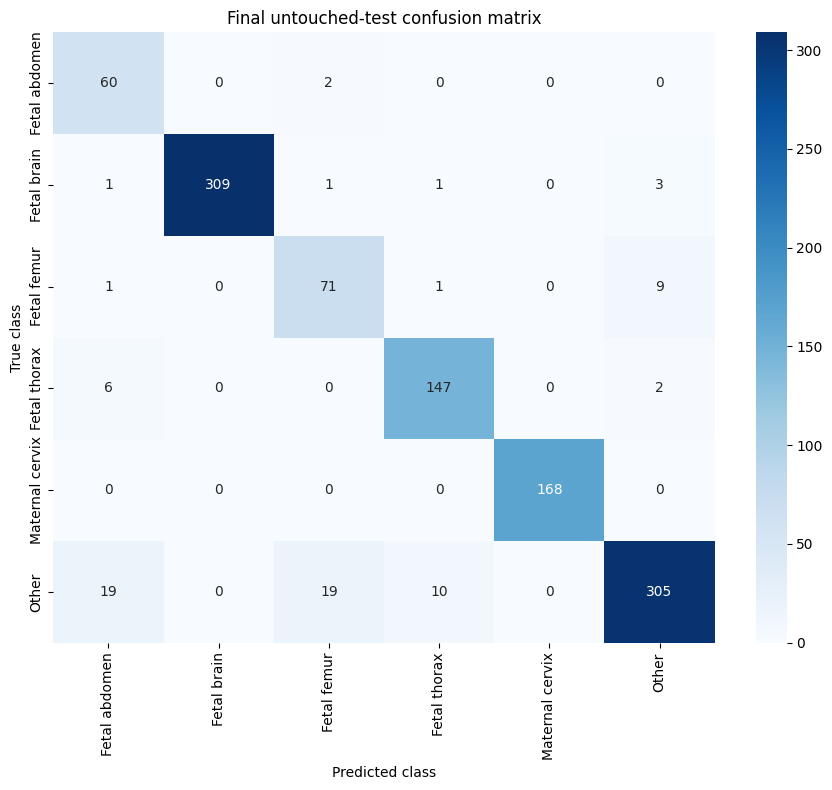

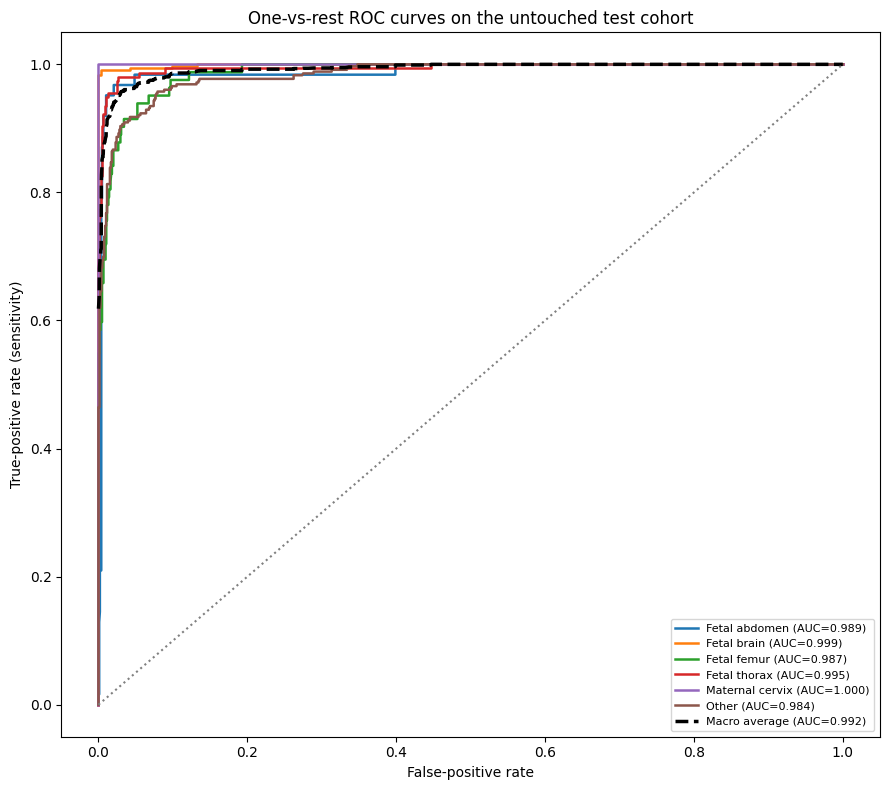


FINAL QGECAF — UNTOUCHED TEST PERFORMANCE
Test support                 : 1135 images
Accuracy                     : 93.39%
Balanced accuracy            : 93.78%
Macro precision              : 88.90%
Macro recall/sensitivity     : 93.78%
Macro specificity            : 98.73%
Macro F1-score               : 90.85%
Weighted F1-score            : 93.57%
Macro OvR ROC-AUC            : 0.9924
Weighted OvR ROC-AUC         : 0.9926
Cohen's kappa                : 0.9159
Matthews correlation         : 0.9168

TRAINING, INFERENCE AND COMPUTATIONAL COMPLEXITY
Exact training time          : 596.030 seconds
Exact training time          : 9.934 minutes
Mean epoch time              : 42.574 seconds
Completed epochs             : 14
Maximum configured epochs    : 50
Inference time               : 3.016 ms/image
Total parameters             : 2,416,583
Trainable parameters         : 1,684,999
TensorFlow GFLOPs/image      : 0.1984
Approximate GMACs/image      : 0.0992

Class-wise results:


,class,support,precision,sensitivity,specificity,f1_score,roc_auc_ovr
0,Fetal abdomen,62,0.6897,0.9677,0.9748,0.8054,0.9890
1,Fetal brain,315,1.0000,0.9810,1.0000,0.9904,0.9991
2,Fetal femur,82,0.7634,0.8659,0.9791,0.8114,0.9873
3,Fetal thorax,155,0.9245,0.9484,0.9878,0.9363,0.9945
4,Maternal cervix,168,1.0000,1.0000,1.0000,1.0000,1.0000
5,Other,353,0.9561,0.8640,0.9821,0.9077,0.9841



Results saved in:
D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01\final_timed_model_test_evaluation


In [20]:
# =====================================================================
# FINAL TIMED MODEL — UNTOUCHED TEST EVALUATION AND COMPLEXITY
# =====================================================================

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize


# ---------------------------------------------------------------------
# 1. EXPERIMENT INFORMATION
# ---------------------------------------------------------------------

RESULT_ROOT = Path(
    r"D:\chaitali\qgacef\QGECAF_FROM_SCRATCH_RUN_01"
)

FINAL_EVAL_DIR = RESULT_ROOT / "final_timed_model_test_evaluation"
FINAL_EVAL_DIR.mkdir(parents=True, exist_ok=True)

# Exact measurements obtained from the timing rerun
EXACT_TRAINING_TIME_SECONDS = 596.030
COMPLETED_EPOCHS = 14
MAXIMUM_CONFIGURED_EPOCHS = 50

MEAN_EPOCH_TIME_SECONDS = (
    EXACT_TRAINING_TIME_SECONDS / COMPLETED_EPOCHS
)

INFERENCE_BATCH_SIZE = 16


# ---------------------------------------------------------------------
# 2. CHECK REQUIRED OBJECTS
# ---------------------------------------------------------------------
# Run this cell in the same kernel/session as the exact timing cell.

required_objects = [
    "final_model",
    "raw",
    "transformed",
    "quality_z",
    "test_idx",
    "class_names",
    "make_inputs",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following objects are not available:\n"
        f"{missing_objects}\n\n"
        "Run the QGECAF definition/configuration cells and the exact final "
        "training-time cell before running this evaluation cell."
    )


# ---------------------------------------------------------------------
# 3. PREPARE UNTOUCHED TEST INPUTS
# ---------------------------------------------------------------------

class_names = [str(name) for name in class_names]
num_classes = len(class_names)

x_test = make_inputs(
    raw,
    transformed,
    quality_z,
    test_idx,
)

y_test = np.asarray(raw["labels"])[test_idx].astype(int)
test_paths = np.asarray(raw["paths"])[test_idx]

if len(y_test) != 1135:
    raise RuntimeError(
        f"Expected 1,135 untouched test images, but found {len(y_test)}."
    )

if num_classes != 6:
    raise RuntimeError(
        f"Expected 6 classes, but found {num_classes}: {class_names}"
    )

print("Untouched test images:", len(y_test))
print("Classes:", class_names)


# ---------------------------------------------------------------------
# 4. PREDICT AND MEASURE INFERENCE TIME
# ---------------------------------------------------------------------

# Warm-up prediction is excluded from reported inference time.
warmup_size = min(INFERENCE_BATCH_SIZE, len(y_test))
warmup_inputs = {
    key: value[:warmup_size]
    for key, value in x_test.items()
}

_ = final_model.predict(
    warmup_inputs,
    batch_size=INFERENCE_BATCH_SIZE,
    verbose=0,
)

inference_start = time.perf_counter()

model_output = final_model.predict(
    x_test,
    batch_size=INFERENCE_BATCH_SIZE,
    verbose=1,
)

inference_time_seconds = time.perf_counter() - inference_start
inference_time_ms_per_image = (
    inference_time_seconds / len(y_test)
) * 1000.0


# ---------------------------------------------------------------------
# 5. CONVERT DIRICHLET OUTPUT TO CLASS PROBABILITIES
# ---------------------------------------------------------------------
# The QGECAF model outputs Dirichlet alpha values:
#
#     p_k = alpha_k / sum(alpha)

model_output = np.asarray(model_output, dtype=np.float64)

if model_output.ndim != 2:
    raise ValueError(
        f"Expected a two-dimensional model output; got {model_output.shape}."
    )

if np.all(model_output >= 1.0):
    # Evidential QGECAF output
    alpha = model_output
    probabilities = alpha / np.sum(
        alpha,
        axis=1,
        keepdims=True,
    )
else:
    # Fallback for a softmax-output model
    probabilities = model_output / np.sum(
        model_output,
        axis=1,
        keepdims=True,
    )

y_pred = np.argmax(probabilities, axis=1)


# ---------------------------------------------------------------------
# 6. CONFUSION MATRIX AND CLASS-WISE METRICS
# ---------------------------------------------------------------------

labels = np.arange(num_classes)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
)

total_samples = int(cm.sum())
class_rows = []

y_test_binary = label_binarize(
    y_test,
    classes=labels,
)

for class_index, class_name in enumerate(class_names):

    true_positive = int(cm[class_index, class_index])
    false_negative = int(
        cm[class_index, :].sum() - true_positive
    )
    false_positive = int(
        cm[:, class_index].sum() - true_positive
    )
    true_negative = int(
        total_samples
        - true_positive
        - false_negative
        - false_positive
    )

    support = true_positive + false_negative

    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0.0
    )

    sensitivity = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0.0
    )

    specificity = (
        true_negative / (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else 0.0
    )

    f1 = (
        2.0 * precision * sensitivity /
        (precision + sensitivity)
        if (precision + sensitivity) > 0
        else 0.0
    )

    ovr_accuracy = (
        true_positive + true_negative
    ) / total_samples

    # One-vs-rest ROC-AUC
    if len(np.unique(y_test_binary[:, class_index])) == 2:
        class_roc_auc = roc_auc_score(
            y_test_binary[:, class_index],
            probabilities[:, class_index],
        )
    else:
        class_roc_auc = float("nan")

    class_rows.append(
        {
            "class": class_name,
            "support": support,
            "true_positive": true_positive,
            "false_positive": false_positive,
            "false_negative": false_negative,
            "true_negative": true_negative,
            "precision": precision,
            "recall": sensitivity,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "f1_score": f1,
            "ovr_accuracy": ovr_accuracy,
            "roc_auc_ovr": class_roc_auc,
        }
    )

classwise_metrics = pd.DataFrame(class_rows)

classwise_metrics.to_csv(
    FINAL_EVAL_DIR / "final_classwise_metrics.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 7. OVERALL METRICS
# ---------------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

macro_specificity = classwise_metrics[
    "specificity"
].mean()

weighted_specificity = np.average(
    classwise_metrics["specificity"],
    weights=classwise_metrics["support"],
)

cohen_kappa = cohen_kappa_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)

macro_roc_auc = roc_auc_score(
    y_test_binary,
    probabilities,
    average="macro",
    multi_class="ovr",
)

weighted_roc_auc = roc_auc_score(
    y_test_binary,
    probabilities,
    average="weighted",
    multi_class="ovr",
)


# ---------------------------------------------------------------------
# 8. GFLOPs PER IMAGE
# ---------------------------------------------------------------------

def calculate_tensorflow_gflops(model):
    """
    Estimate the floating-point operations for one forward pass with
    batch size 1 using the TensorFlow graph profiler.

    TensorFlow counts multiplication and addition as separate operations.
    """

    from tensorflow.python.framework.convert_to_constants import (
        convert_variables_to_constants_v2,
    )

    input_specs = []

    for model_input in model.inputs:
        input_shape = [
            1 if dimension is None else int(dimension)
            for dimension in model_input.shape
        ]

        input_specs.append(
            tf.TensorSpec(
                shape=input_shape,
                dtype=tf.as_dtype(model_input.dtype),
                name=model_input.name.split(":")[0],
            )
        )

    @tf.function
    def forward_pass(*model_inputs):
        return model(
            list(model_inputs),
            training=False,
        )

    concrete_function = forward_pass.get_concrete_function(
        *input_specs
    )

    frozen_function = convert_variables_to_constants_v2(
        concrete_function
    )

    graph_definition = frozen_function.graph.as_graph_def()

    with tf.Graph().as_default() as profiling_graph:

        tf.graph_util.import_graph_def(
            graph_definition,
            name="",
        )

        profiler_options = (
            tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        )

        profiler_options["output"] = "none"

        profile = tf.compat.v1.profiler.profile(
            profiling_graph,
            options=profiler_options,
        )

    if profile is None:
        return float("nan"), float("nan")

    total_flops = int(profile.total_float_ops)
    gflops = total_flops / 1e9

    # Approximate GMACs when one multiply–accumulate is treated as two FLOPs.
    approximate_gmacs = total_flops / 2e9

    return gflops, approximate_gmacs


try:
    gflops_per_image, approximate_gmacs = (
        calculate_tensorflow_gflops(final_model)
    )
except Exception as error:
    print("GFLOPs calculation warning:", error)
    gflops_per_image = float("nan")
    approximate_gmacs = float("nan")


# ---------------------------------------------------------------------
# 9. MODEL PARAMETERS
# ---------------------------------------------------------------------

total_parameters = int(final_model.count_params())

trainable_parameters = int(
    np.sum(
        [
            np.prod(variable.shape)
            for variable in final_model.trainable_weights
        ]
    )
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)


# ---------------------------------------------------------------------
# 10. OVERALL PUBLICATION SUMMARY
# ---------------------------------------------------------------------

overall_metrics = {
    "test_images": int(len(y_test)),
    "test_support": int(len(y_test)),

    "accuracy": float(accuracy),
    "accuracy_percent": float(accuracy * 100.0),

    "balanced_accuracy": float(balanced_accuracy),
    "balanced_accuracy_percent": float(
        balanced_accuracy * 100.0
    ),

    "macro_precision": float(macro_precision),
    "weighted_precision": float(weighted_precision),

    "macro_recall_sensitivity": float(macro_recall),
    "weighted_recall_sensitivity": float(weighted_recall),

    "macro_specificity": float(macro_specificity),
    "weighted_specificity": float(weighted_specificity),

    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),

    "macro_roc_auc_ovr": float(macro_roc_auc),
    "weighted_roc_auc_ovr": float(weighted_roc_auc),

    "cohen_kappa": float(cohen_kappa),
    "mcc": float(mcc),

    "completed_epochs": int(COMPLETED_EPOCHS),
    "maximum_configured_epochs": int(
        MAXIMUM_CONFIGURED_EPOCHS
    ),

    "training_time_seconds": float(
        EXACT_TRAINING_TIME_SECONDS
    ),
    "training_time_minutes": float(
        EXACT_TRAINING_TIME_SECONDS / 60.0
    ),
    "mean_epoch_time_seconds": float(
        MEAN_EPOCH_TIME_SECONDS
    ),

    "inference_time_seconds": float(
        inference_time_seconds
    ),
    "inference_time_ms_per_image": float(
        inference_time_ms_per_image
    ),

    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "non_trainable_parameters": non_trainable_parameters,

    "tensorflow_gflops_per_image": float(
        gflops_per_image
    ),
    "approximate_gmacs_per_image": float(
        approximate_gmacs
    ),
}

with open(
    FINAL_EVAL_DIR / "final_model_complete_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        overall_metrics,
        file,
        indent=4,
    )

pd.DataFrame(
    [
        {
            "Metric": key,
            "Value": value,
        }
        for key, value in overall_metrics.items()
    ]
).to_csv(
    FINAL_EVAL_DIR / "final_model_complete_metrics.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 11. SAVE INDIVIDUAL TEST PREDICTIONS
# ---------------------------------------------------------------------

prediction_table = pd.DataFrame(
    {
        "path": test_paths,
        "true_index": y_test,
        "true_class": [
            class_names[index]
            for index in y_test
        ],
        "predicted_index": y_pred,
        "predicted_class": [
            class_names[index]
            for index in y_pred
        ],
        "correct": y_test == y_pred,
        "confidence": probabilities.max(axis=1),
    }
)

for class_index, class_name in enumerate(class_names):
    prediction_table[
        f"probability_{class_name}"
    ] = probabilities[:, class_index]

prediction_table.to_csv(
    FINAL_EVAL_DIR / "final_test_predictions.csv",
    index=False,
)


# ---------------------------------------------------------------------
# 12. SAVE CONFUSION MATRIX
# ---------------------------------------------------------------------

plt.figure(figsize=(9, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Final untouched-test confusion matrix")
plt.tight_layout()

plt.savefig(
    FINAL_EVAL_DIR / "final_test_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ---------------------------------------------------------------------
# 13. SAVE MULTICLASS ROC CURVES
# ---------------------------------------------------------------------

plt.figure(figsize=(9, 8))

all_fpr_values = []
class_tpr_curves = []

for class_index, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, class_index],
        probabilities[:, class_index],
    )

    class_auc = auc(fpr, tpr)

    all_fpr_values.append(fpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=1.8,
        label=f"{class_name} (AUC={class_auc:.3f})",
    )

# Interpolated macro-average ROC curve
common_fpr = np.unique(
    np.concatenate(all_fpr_values)
)

mean_tpr = np.zeros_like(common_fpr)

for class_index in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_test_binary[:, class_index],
        probabilities[:, class_index],
    )

    mean_tpr += np.interp(
        common_fpr,
        fpr,
        tpr,
    )

mean_tpr /= num_classes
macro_curve_auc = auc(common_fpr, mean_tpr)

plt.plot(
    common_fpr,
    mean_tpr,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Macro average (AUC={macro_curve_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
)

plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate (sensitivity)")
plt.title("One-vs-rest ROC curves on the untouched test cohort")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()

plt.savefig(
    FINAL_EVAL_DIR / "final_test_roc_curves.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ---------------------------------------------------------------------
# 14. DISPLAY RESULTS
# ---------------------------------------------------------------------

print("\n" + "=" * 74)
print("FINAL QGECAF — UNTOUCHED TEST PERFORMANCE")
print("=" * 74)

print(f"Test support                 : {len(y_test)} images")
print(f"Accuracy                     : {accuracy * 100:.2f}%")
print(
    f"Balanced accuracy            : "
    f"{balanced_accuracy * 100:.2f}%"
)
print(
    f"Macro precision              : "
    f"{macro_precision * 100:.2f}%"
)
print(
    f"Macro recall/sensitivity     : "
    f"{macro_recall * 100:.2f}%"
)
print(
    f"Macro specificity            : "
    f"{macro_specificity * 100:.2f}%"
)
print(f"Macro F1-score               : {macro_f1 * 100:.2f}%")
print(f"Weighted F1-score            : {weighted_f1 * 100:.2f}%")
print(f"Macro OvR ROC-AUC            : {macro_roc_auc:.4f}")
print(f"Weighted OvR ROC-AUC         : {weighted_roc_auc:.4f}")
print(f"Cohen's kappa                : {cohen_kappa:.4f}")
print(f"Matthews correlation         : {mcc:.4f}")

print("\n" + "=" * 74)
print("TRAINING, INFERENCE AND COMPUTATIONAL COMPLEXITY")
print("=" * 74)

print(
    f"Exact training time          : "
    f"{EXACT_TRAINING_TIME_SECONDS:.3f} seconds"
)
print(
    f"Exact training time          : "
    f"{EXACT_TRAINING_TIME_SECONDS / 60:.3f} minutes"
)
print(
    f"Mean epoch time              : "
    f"{MEAN_EPOCH_TIME_SECONDS:.3f} seconds"
)
print(f"Completed epochs             : {COMPLETED_EPOCHS}")
print(f"Maximum configured epochs    : {MAXIMUM_CONFIGURED_EPOCHS}")
print(
    f"Inference time               : "
    f"{inference_time_ms_per_image:.3f} ms/image"
)
print(f"Total parameters             : {total_parameters:,}")
print(f"Trainable parameters         : {trainable_parameters:,}")
print(
    f"TensorFlow GFLOPs/image      : "
    f"{gflops_per_image:.4f}"
)
print(
    f"Approximate GMACs/image      : "
    f"{approximate_gmacs:.4f}"
)

print("\nClass-wise results:")
display(
    classwise_metrics[
        [
            "class",
            "support",
            "precision",
            "sensitivity",
            "specificity",
            "f1_score",
            "roc_auc_ovr",
        ]
    ].round(4)
)

print("\nResults saved in:")
print(FINAL_EVAL_DIR)

In [3]:
import tensorflow as tf

print("LAYER NORMALIZATION LAYERS")
print("=" * 90)

for layer in final_model.submodules:
    if isinstance(
        layer,
        tf.keras.layers.LayerNormalization
    ):
        try:
            output_shape = layer.output_shape
        except Exception:
            output_shape = "Unavailable"

        print(
            f"{layer.name:<40} "
            f"parameters={layer.count_params():<6} "
            f"output={output_shape}"
        )

LAYER NORMALIZATION LAYERS


NameError: name 'final_model' is not defined

In [4]:
import tensorflow as tf

model_objects = {}

for name, value in globals().items():
    if isinstance(value, tf.keras.Model):
        model_objects[name] = value

print("Keras models currently available:")
print("=" * 70)

if model_objects:
    for name, model_object in model_objects.items():
        print(
            f"{name:<30} "
            f"name={model_object.name:<25} "
            f"parameters={model_object.count_params():,}"
        )
else:
    print("No Keras model object is currently available.")

RuntimeError: dictionary changed size during iteration